# EDA_AGENT: structured Cifrium LMS EDA and feature pipeline

Goal: build a professional, auditable, ML-oriented EDA in grain `(user_id, course_id)`.

Main principles:
- keep source notebooks and raw data read-only;
- reuse useful logic from `EDA.ipynb`, `Resolve_id.ipynb`, `Resolve_AGENT.ipynb`;
- split rough preprocessing table by table;
- restore `(user_id, course_id) -> users_course_id` in a dedicated block close to `Resolve_AGENT.ipynb`;
- validate every important join;
- build interpretable feature blocks aligned with churn/success analysis;
- save only ASCII outputs to `data/AGENTS`.


## 0. Safety and notebook map

Protected files are read-only references: `notebooks/EDA.ipynb`, `notebooks/Resolve_id.ipynb`, `notebooks/Resolve_AGENT.ipynb`, `data/raw`, `README.md`, `Hipotises.md`.

This notebook writes outputs only to `data/AGENTS`.

Notebook map:
1. Environment and config.
2. Data loading and source audit.
3. Rough preprocessing by table.
4. Key restoration block.
5. Resolution and join audit.
6. Table-by-table feature engineering.
7. Hypothesis checks with metrics and plots.
8. Final merge and final audit.
9. Export artifacts and final summary.


## 1. Environment, imports, config

`UNRESOLVED_MODE` controls unresolved key handling.

`keep`: keep unresolved `(user_id, course_id)` rows. For downstream course-activity features, unresolved rows keep `NA` because the bridge is unknown; resolved rows with no events get zero-like event counts.

`drop`: drop unresolved rows before final modeling table export.


In [1]:
import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 260)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "data" / "AGENTS"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

UNRESOLVED_MODE = "keep"
TARGET_INACTIVITY_DAYS = 30
MIN_COURSE_ROWS_FOR_COURSE_AUDIT = 10
USER_ANSWERS_CHUNK_SIZE = 500_000

if UNRESOLVED_MODE not in {"keep", "drop"}:
    raise ValueError("UNRESOLVED_MODE must be keep or drop")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("UNRESOLVED_MODE:", UNRESOLVED_MODE)


PROJECT_ROOT: C:\Repos\Xakaton
DATA_DIR: C:\Repos\Xakaton\data\raw
OUTPUT_DIR: C:\Repos\Xakaton\data\AGENTS
UNRESOLVED_MODE: keep


In [2]:
def to_int_id(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        numeric = pd.to_numeric(series, errors="coerce")
    else:
        numeric = pd.to_numeric(series.astype("string").str.replace(",", "", regex=False), errors="coerce")
    return numeric.astype("Int64")

def to_bool01(series: pd.Series) -> pd.Series:
    return series.astype("string").str.strip().str.lower().isin(["true", "1", "yes"]).astype("Int8")

def safe_div(num, den):
    num = pd.to_numeric(num, errors="coerce")
    den = pd.to_numeric(den, errors="coerce")
    return np.where(den > 0, num / den, np.nan)

def clean_name(value) -> str:
    value = str(value).strip().lower()
    value = re.sub(r"[^a-z0-9]+", "_", value)
    value = re.sub(r"_+", "_", value).strip("_")
    return value or "unknown"

def missingness_table(df: pd.DataFrame, top_n: int = 200) -> pd.DataFrame:
    return pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_share": df.isna().mean().values,
        "dtype": [str(df[c].dtype) for c in df.columns],
    }).sort_values(["missing_share", "missing_count"], ascending=False).head(top_n).reset_index(drop=True)

def merge_many_to_one(base: pd.DataFrame, add: pd.DataFrame, keys, name: str, audit_rows: list, how: str = "left") -> pd.DataFrame:
    before_rows = len(base)
    out = base.merge(add, on=keys, how=how, validate="many_to_one")
    audit_rows.append({
        "merge_name": name,
        "keys": "|".join(keys),
        "how": how,
        "rows_before": before_rows,
        "rows_after": len(out),
        "row_delta": len(out) - before_rows,
        "base_duplicate_keys_before": int(base.duplicated(keys).sum()),
        "add_duplicate_keys": int(add.duplicated(keys).sum()),
        "duplicate_keys_after": int(out.duplicated(keys).sum()),
    })
    return out

def plot_bar(series, title, xlabel, ylabel, figsize=(6, 3)):
    plt.figure(figsize=figsize)
    series.plot(kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def display_head(df, n=10):
    display(df.head(n))


## 2. Data loading setup

This block mirrors the style of the source EDA: file map, date column map, and one loader function.

`user_answers` is intentionally not loaded here because it is very large; it is processed later in chunks as user-level enrichment.


In [3]:
FILES = {
    "users_courses": "users_courses.csv",
    "users": "users.csv",
    "lessons": "lessons.csv",
    "user_lessons": "user_lessons.csv",
    "wk_users_courses_actions": "wk_users_courses_actions.csv",
    "user_access_histories": "user_access_histories.csv",
    "user_activity_histories": "user_activity_histories.csv",
    "user_trainings": "user_trainings.csv",
    "wk_media_view_sessions": "wk_media_view_sessions.csv",
    "user_award_badges": "user_award_badges.csv",
    "award_badges": "award_badges.csv",
}

USECOLS = {
    "users_courses": ["user_id", "course_id", "state", "created_at", "updated_at", "access_finished_at", "wk_points", "wk_max_points", "wk_max_viewable_lessons", "wk_max_task_count", "wk_officially_started_at", "wk_course_completed_at"],
    "users": ["id", "type", "created_at", "sign_in_count", "grade_id", "subscribed", "timezone", "d_wk_school_id", "d_wk_municipal_id", "d_wk_region_id", "wk_gender"],
    "lessons": ["course_id", "conspect_expected", "task_expected", "lesson_number", "wk_max_points", "wk_task_count", "wk_survival_training_expected", "wk_scratch_playground_enabled", "wk_attendance_tracking_enabled", "wk_video_duration"],
    "user_lessons": ["Unnamed: 0", "user_id", "lesson_id", "group_id", "video_visited", "translation_visited", "users_course_id", "solved", "solved_tasks_count", "wk_points", "video_viewed", "wk_solved_task_count"],
    "wk_users_courses_actions": ["user_id", "users_course_id", "action", "created_at", "updated_at", "lesson_id"],
    "user_access_histories": ["users_course_id", "access_started_at", "access_expired_at", "activator_class"],
    "user_activity_histories": ["user_lesson_id", "action", "created_at"],
    "user_trainings": ["user_id", "training_id", "solved_tasks_count", "earned_points", "type", "state", "submitted_answers_count", "started_at", "finished_at", "attempts", "mark", "mark_saved_at"],
    "wk_media_view_sessions": ["resource_type", "viewer_id", "segments_total", "viewed_segments_count", "started_at", "kind"],
    "user_award_badges": ["award_badge_id", "user_id", "created_at"],
    "award_badges": ["Unnamed: 0", "name", "title", "level", "quota", "special"],
}

DATE_COLS = {
    "users_courses": ["created_at", "updated_at", "access_finished_at", "wk_officially_started_at", "wk_course_completed_at"],
    "users": ["created_at"],
    "wk_users_courses_actions": ["created_at", "updated_at"],
    "user_access_histories": ["access_started_at", "access_expired_at"],
    "user_activity_histories": ["created_at"],
    "user_trainings": ["started_at", "finished_at", "mark_saved_at"],
    "wk_media_view_sessions": ["started_at"],
    "user_award_badges": ["created_at"],
}

def load_tables(data_dir: Path, files: dict, usecols: dict) -> tuple[dict, pd.DataFrame]:
    dfs_local = {}
    overview = []
    for table_name, filename in files.items():
        df = pd.read_csv(data_dir / filename, usecols=usecols[table_name], encoding="utf-8", low_memory=False)
        dfs_local[table_name] = df
        overview.append({"table": table_name, "rows": len(df), "cols": df.shape[1], "memory_mb": round(df.memory_usage(deep=True).sum() / 1024**2, 2)})
    return dfs_local, pd.DataFrame(overview).sort_values("table").reset_index(drop=True)

dfs, source_overview_AGENTS = load_tables(DATA_DIR, FILES, USECOLS)
display(source_overview_AGENTS)


,table,rows,cols,memory_mb
0,award_badges,6,6,0.00
1,lessons,3369,10,0.31
2,user_access_histories,667124,4,160.11
3,user_activity_histories,3031137,3,606.62
4,user_award_badges,252843,3,35.62
5,user_lessons,3070664,12,844.95
6,user_trainings,427628,12,221.22
7,users,95395,11,46.59
8,users_courses,290835,12,172.23
9,wk_media_view_sessions,852358,6,231.02


## 3. Source table overview and duplicate audit

Before preprocessing, check source shapes and full-row duplicates. Event tables can have repeated-looking rows, so this block reports duplicates but does not blindly drop them.


In [4]:
schema_rows = []
for csv_path in sorted(DATA_DIR.glob("*.csv")):
    cols = pd.read_csv(csv_path, nrows=0, encoding="utf-8").columns.tolist()
    schema_rows.append({"table": csv_path.stem, "column_count": len(cols), "columns_preview": "|".join([clean_name(c) for c in cols[:8]])})
source_schema_AGENTS = pd.DataFrame(schema_rows)
display(source_schema_AGENTS)

duplicate_audit_AGENTS = pd.DataFrame([
    {"table": name, "rows": len(df), "full_duplicate_rows": int(df.duplicated().sum()), "full_duplicate_share": float(df.duplicated().mean()) if len(df) else 0.0}
    for name, df in dfs.items()
]).sort_values("full_duplicate_rows", ascending=False).reset_index(drop=True)
display(duplicate_audit_AGENTS)


,table,column_count,columns_preview
0,award_badges,7,unnamed_0|name|title|level|quota|special|unlocked_small_image_url
1,lessons,12,unnamed_0|course_id|conspect_expected|task_expected|lesson_number|wk_max_points|wk_task_count|wk_survival_training_expected
2,user_access_histories,5,unnamed_0|users_course_id|access_started_at|access_expired_at|activator_class
3,user_activity_histories,4,unnamed_0|user_lesson_id|action|created_at
4,user_answers,14,unnamed_0|user_id|task_id|attempts|solved|points|max_attempts|results
5,user_award_badges,4,unnamed_0|award_badge_id|user_id|created_at
6,user_lessons,12,unnamed_0|user_id|lesson_id|group_id|video_visited|translation_visited|users_course_id|solved
7,user_trainings,13,unnamed_0|user_id|training_id|solved_tasks_count|earned_points|type|state|submitted_answers_count
8,users,22,unnamed_0|id|last_explainer_seen_course|created_at|updated_at|type|remember_created_at|sign_in_count
9,users_courses,13,unnamed_0|user_id|course_id|state|created_at|updated_at|access_finished_at|wk_points


,table,rows,full_duplicate_rows,full_duplicate_share
0,wk_users_courses_actions,12909207,5491157,0.425367
1,user_access_histories,667124,355372,0.532693
2,user_activity_histories,3031137,33312,0.010990
3,wk_media_view_sessions,852358,22183,0.026025
4,lessons,3369,1814,0.538439
5,users,95395,0,0.000000
6,users_courses,290835,0,0.000000
7,user_lessons,3070664,0,0.000000
8,user_trainings,427628,0,0.000000
9,user_award_badges,252843,0,0.000000


## 4. Rough preprocessing by table

This section follows the source EDA style: each table is processed in its own cell. The goal is not to over-refactor, but to keep all cleaning decisions visible and auditable.


### 4.1 `users_courses` rough preprocessing

`users_courses` is the master table. It defines the target grain `(user_id, course_id)` and keeps course status/progress fields. `state` is not used as final target; it is kept only as a status/audit column.


In [5]:
uc = dfs["users_courses"].copy()
for col in ["user_id", "course_id"]:
    uc[col] = to_int_id(uc[col])
for col in ["wk_points", "wk_max_points", "wk_max_viewable_lessons", "wk_max_task_count"]:
    uc[col] = pd.to_numeric(uc[col], errors="coerce")
for col in DATE_COLS["users_courses"]:
    uc[col] = pd.to_datetime(uc[col], errors="coerce")
uc["uc_is_active_state"] = uc["state"].astype("string").str.lower().eq("active").astype("Int8")
uc["uc_is_completed_flag"] = uc["wk_course_completed_at"].notna().astype("Int8")
uc["uc_points_ratio"] = safe_div(uc["wk_points"], uc["wk_max_points"])
uc["uc_access_window_days"] = (uc["access_finished_at"] - uc["created_at"]).dt.days
uc["uc_days_start_to_official_start"] = (uc["wk_officially_started_at"] - uc["created_at"]).dt.days
uc["uc_task_capacity_ratio"] = safe_div(uc["wk_max_task_count"], uc["wk_max_viewable_lessons"])
dfs["users_courses"] = uc
users_courses_preprocess_audit = pd.DataFrame([{"metric": "rows", "value": len(uc)}, {"metric": "unique_user_course_pairs", "value": uc[["user_id", "course_id"]].drop_duplicates().shape[0]}, {"metric": "duplicate_user_course_pairs", "value": int(uc.duplicated(["user_id", "course_id"]).sum())}, {"metric": "state_active_share", "value": float(uc["uc_is_active_state"].mean())}, {"metric": "course_completed_share", "value": float(uc["uc_is_completed_flag"].mean())}])
display(users_courses_preprocess_audit)


,metric,value
0,rows,290835.000000
1,unique_user_course_pairs,290835.000000
2,duplicate_user_course_pairs,0.000000
3,state_active_share,0.988698
4,course_completed_share,0.001217


### 4.2 `users` rough preprocessing and teacher ids

Teacher/account-agent filtering follows the source EDA: `users.type` containing `Agent` is treated as teacher-like account.


In [6]:
users = dfs["users"].copy()
for col in ["id", "sign_in_count", "grade_id", "d_wk_school_id", "d_wk_municipal_id", "d_wk_region_id"]:
    users[col] = to_int_id(users[col])
users["created_at"] = pd.to_datetime(users["created_at"], errors="coerce")
users["user_id"] = users["id"].copy()
users["is_teacher_agent"] = users["type"].astype("string").str.contains("Agent", na=False)
teacher_ids = set(users.loc[users["is_teacher_agent"], "user_id"].dropna().astype("int64"))
users["user_subscribed_flag"] = to_bool01(users["subscribed"])
dfs["users"] = users
users_preprocess_audit = pd.DataFrame([{"metric": "users_rows", "value": len(users)}, {"metric": "teacher_agent_users", "value": len(teacher_ids)}, {"metric": "pupil_like_users", "value": int((~users["is_teacher_agent"]).sum())}])
display(users_preprocess_audit)


,metric,value
0,users_rows,95395
1,teacher_agent_users,4748
2,pupil_like_users,90647


### 4.3 `lessons` rough preprocessing

`lessons` is a course-level reference source. It is useful for compact course metadata, but it should not overwrite `users_courses` fields without audit because source EDA found mismatches.


In [7]:
lessons = dfs["lessons"].copy()
lessons["course_id"] = to_int_id(lessons["course_id"])
for col in ["wk_max_points", "wk_task_count", "wk_video_duration", "lesson_number"]:
    lessons[col] = pd.to_numeric(lessons[col], errors="coerce")
for col in ["conspect_expected", "task_expected", "wk_survival_training_expected", "wk_scratch_playground_enabled", "wk_attendance_tracking_enabled"]:
    lessons[col] = to_bool01(lessons[col])
dfs["lessons"] = lessons
lessons_preprocess_audit = pd.DataFrame([{"metric": "lessons_rows", "value": len(lessons)}, {"metric": "course_id_nunique", "value": lessons["course_id"].nunique()}, {"metric": "task_expected_share", "value": float(lessons["task_expected"].mean())}])
display(lessons_preprocess_audit)


,metric,value
0,lessons_rows,3369.000000
1,course_id_nunique,137.000000
2,task_expected_share,0.735233


### 4.4 `user_lessons` rough preprocessing

`user_lessons` is the main lesson-progress table and one of the strongest sources for restoring `users_course_id`. The technical CSV row id is kept as `user_lesson_row_id` for the `user_activity_histories` bridge audit.


In [8]:
ul = dfs["user_lessons"].copy().rename(columns={"Unnamed: 0": "user_lesson_row_id"})
for col in ["user_lesson_row_id", "user_id", "lesson_id", "group_id", "users_course_id"]:
    ul[col] = to_int_id(ul[col])
for col in ["video_visited", "translation_visited", "solved", "video_viewed"]:
    ul[col] = to_bool01(ul[col])
for col in ["solved_tasks_count", "wk_points", "wk_solved_task_count"]:
    ul[col] = pd.to_numeric(ul[col], errors="coerce")
dfs["user_lessons"] = ul
user_lessons_preprocess_audit = pd.DataFrame([{"metric": "user_lessons_rows", "value": len(ul)}, {"metric": "users_course_id_nunique", "value": ul["users_course_id"].nunique()}, {"metric": "max_user_id_per_users_course_id", "value": ul.groupby("users_course_id")["user_id"].nunique().max()}, {"metric": "video_visited_share", "value": float(ul["video_visited"].mean())}])
display(user_lessons_preprocess_audit)


,metric,value
0,user_lessons_rows,3.070664e+06
1,users_course_id_nunique,2.164820e+05
2,max_user_id_per_users_course_id,1.000000e+00
3,video_visited_share,8.048865e-01


### 4.5 `wk_users_courses_actions` rough preprocessing

This is the main course-action event log. It supports recency, frequency, diversity, activity gaps and target-related inactivity logic.


In [9]:
wka = dfs["wk_users_courses_actions"].copy()
for col in ["user_id", "users_course_id", "lesson_id"]:
    wka[col] = to_int_id(wka[col])
for col in ["created_at", "updated_at"]:
    wka[col] = pd.to_datetime(wka[col], errors="coerce")
wka["action_clean"] = wka["action"].astype("string").map(clean_name)
dfs["wk_users_courses_actions"] = wka
wka_preprocess_audit = pd.DataFrame([{"metric": "wka_rows", "value": len(wka)}, {"metric": "users_course_id_nunique", "value": wka["users_course_id"].nunique()}, {"metric": "max_user_id_per_users_course_id", "value": wka.dropna(subset=["users_course_id"]).groupby("users_course_id")["user_id"].nunique().max()}, {"metric": "action_nunique", "value": wka["action_clean"].nunique()}])
display(wka_preprocess_audit)
display(wka["action_clean"].value_counts().rename_axis("action_clean").reset_index(name="rows"))


,metric,value
0,wka_rows,12909207
1,users_course_id_nunique,216342
2,max_user_id_per_users_course_id,1
3,action_nunique,6


,action_clean,rows
0,user_answer,9698443
1,visit_video,2609769
2,start_training,476487
3,visit_translation,109437
4,visit_preparation_material,15069
5,scratch_playground_visited,2


### 4.6 `user_access_histories` rough preprocessing

This table has `users_course_id` but no `user_id`. It is useful after key restoration and for access-duration hypotheses.


In [10]:
access = dfs["user_access_histories"].copy()
access["users_course_id"] = to_int_id(access["users_course_id"])
for col in ["access_started_at", "access_expired_at"]:
    access[col] = pd.to_datetime(access[col], errors="coerce")
access["activator_clean"] = access["activator_class"].astype("string").str.split("::").str[-1].map(clean_name)
access["access_interval_days"] = (access["access_expired_at"] - access["access_started_at"]).dt.days
dfs["user_access_histories"] = access
access_preprocess_audit = pd.DataFrame([{"metric": "access_rows", "value": len(access)}, {"metric": "users_course_id_nunique", "value": access["users_course_id"].nunique()}, {"metric": "activator_nunique", "value": access["activator_clean"].nunique()}, {"metric": "interval_days_mean", "value": float(access["access_interval_days"].mean())}])
display(access_preprocess_audit)
display(access["activator_clean"].value_counts().rename_axis("activator_clean").reset_index(name="rows"))


,metric,value
0,access_rows,667124.000000
1,users_course_id_nunique,290784.000000
2,activator_nunique,5.000000
3,interval_days_mean,175.557844


,activator_clean,rows
0,premiumaccessactivator,665443
1,revokeaccessactivator,1577
2,changeaccessdurationactivator,54
3,standardaccessactivator,41
4,monthpremiumaccessactivator,9


### 4.7 `user_activity_histories` rough preprocessing

Source EDA treated this table cautiously. Here it is not used as the main activity log. It is tested as auxiliary data through `user_lesson_id -> user_lessons.user_lesson_row_id`.


In [11]:
uahist = dfs["user_activity_histories"].copy()
uahist["user_lesson_id"] = to_int_id(uahist["user_lesson_id"])
uahist["created_at"] = pd.to_datetime(uahist["created_at"], errors="coerce")
uahist["action_clean"] = uahist["action"].astype("string").map(clean_name)
dfs["user_activity_histories"] = uahist
uahist_preprocess_audit = pd.DataFrame([{"metric": "uahist_rows", "value": len(uahist)}, {"metric": "user_lesson_id_nunique", "value": uahist["user_lesson_id"].nunique()}, {"metric": "action_nunique", "value": uahist["action_clean"].nunique()}])
display(uahist_preprocess_audit)
display(uahist["action_clean"].value_counts().rename_axis("action_clean").reset_index(name="rows"))


,metric,value
0,uahist_rows,3031137
1,user_lesson_id_nunique,2546319
2,action_nunique,3


,action_clean,rows
0,visit_video,2642950
1,show_conspect,278340
2,visit_translation,109847


### 4.8 `user_trainings` rough preprocessing

`user_trainings` has no validated course bridge in raw columns, so it is used as user-level enrichment. Marks are useful for success-related proxy checks.


In [12]:
train = dfs["user_trainings"].copy()
for col in ["user_id", "training_id"]:
    train[col] = to_int_id(train[col])
for col in ["started_at", "finished_at", "mark_saved_at"]:
    train[col] = pd.to_datetime(train[col], errors="coerce")
for col in ["solved_tasks_count", "earned_points", "submitted_answers_count", "attempts", "mark"]:
    train[col] = pd.to_numeric(train[col], errors="coerce")
train["type_clean"] = train["type"].astype("string").str.split("::").str[-1].map(clean_name)
train["state_clean"] = train["state"].astype("string").map(clean_name)
train["training_duration_min"] = (train["finished_at"] - train["started_at"]).dt.total_seconds() / 60
train["mark_ge4_flag"] = (train["mark"] >= 4).astype("Int8")
dfs["user_trainings"] = train
training_preprocess_audit = pd.DataFrame([{"metric": "training_rows", "value": len(train)}, {"metric": "user_id_nunique", "value": train["user_id"].nunique()}, {"metric": "mark_nonnull_share", "value": float(train["mark"].notna().mean())}, {"metric": "mark_ge4_share_on_nonnull", "value": float(train.loc[train["mark"].notna(), "mark_ge4_flag"].mean())}])
display(training_preprocess_audit)
display(train["type_clean"].value_counts().rename_axis("type_clean").reset_index(name="rows"))


,metric,value
0,training_rows,427628.000000
1,user_id_nunique,65512.000000
2,mark_nonnull_share,0.992243
3,mark_ge4_share_on_nonnull,0.776817


,type_clean,rows
0,lessontraining,416960
1,regulartraining,6331
2,olympiadtraining,4337


### 4.9 `wk_media_view_sessions` rough preprocessing

Media sessions are joined by `viewer_id -> user_id`, so they are user-level engagement features, not course-specific features.


In [13]:
media = dfs["wk_media_view_sessions"].copy().rename(columns={"viewer_id": "user_id"})
media["user_id"] = to_int_id(media["user_id"])
media["started_at"] = pd.to_datetime(media["started_at"], errors="coerce")
for col in ["segments_total", "viewed_segments_count"]:
    media[col] = pd.to_numeric(media[col], errors="coerce")
media["kind_clean"] = media["kind"].astype("string").map(clean_name)
media["media_view_ratio_row"] = safe_div(media["viewed_segments_count"], media["segments_total"])
dfs["wk_media_view_sessions"] = media
media_preprocess_audit = pd.DataFrame([{"metric": "media_rows", "value": len(media)}, {"metric": "user_id_nunique", "value": media["user_id"].nunique()}, {"metric": "kind_nunique", "value": media["kind_clean"].nunique()}, {"metric": "view_ratio_mean", "value": float(np.nanmean(media["media_view_ratio_row"]))}])
display(media_preprocess_audit)
display(media["kind_clean"].value_counts().rename_axis("kind_clean").reset_index(name="rows"))


,metric,value
0,media_rows,852358.000000
1,user_id_nunique,45096.000000
2,kind_nunique,3.000000
3,view_ratio_mean,0.690761


,kind_clean,rows
0,kinescope,619576
1,ulms_vod,173195
2,ulms_live,59587


### 4.10 `user_award_badges` and `award_badges` rough preprocessing

Awards are user-level motivation/engagement proxies. Raw image/title fields are not used as features.


In [14]:
award_ref = dfs["award_badges"].copy().rename(columns={"Unnamed: 0": "award_badge_id"})
award_ref["award_badge_id"] = to_int_id(award_ref["award_badge_id"])
for col in ["level", "quota"]:
    award_ref[col] = pd.to_numeric(award_ref[col], errors="coerce")
award_ref["special"] = to_bool01(award_ref["special"])
award_ref["award_name_clean"] = award_ref["name"].astype("string").str.split("::").str[-1].map(clean_name)

award_events = dfs["user_award_badges"].copy()
award_events["award_badge_id"] = to_int_id(award_events["award_badge_id"])
award_events["user_id"] = to_int_id(award_events["user_id"])
award_events["created_at"] = pd.to_datetime(award_events["created_at"], errors="coerce")
dfs["award_badges"] = award_ref
dfs["user_award_badges"] = award_events
award_preprocess_audit = pd.DataFrame([{"metric": "award_ref_rows", "value": len(award_ref)}, {"metric": "award_events_rows", "value": len(award_events)}, {"metric": "award_user_nunique", "value": award_events["user_id"].nunique()}])
display(award_preprocess_audit)
display(award_ref[["award_badge_id", "award_name_clean", "level", "quota", "special"]])


,metric,value
0,award_ref_rows,6
1,award_events_rows,252843
2,award_user_nunique,68346


,award_badge_id,award_name_clean,level,quota,special
0,0,olympiadparticipant,1,1,1
1,1,solving,1,5,0
2,2,solving,2,25,0
3,3,solving,3,50,0
4,4,solving,4,100,0
5,5,solving,5,500,0


### 4.11 Teacher filter applied to user-keyed tables

This step follows source EDA and removes teacher/account-agent users from all tables that have a user-like key. `user_access_histories` is not filtered here because it has no `user_id`.


In [15]:
teacher_filter_audit_rows = []
for table in ["users_courses", "user_lessons", "wk_users_courses_actions", "user_trainings", "user_award_badges"]:
    before = len(dfs[table])
    dfs[table] = dfs[table].loc[~dfs[table]["user_id"].isin(teacher_ids)].copy()
    teacher_filter_audit_rows.append({"table": table, "checked_column": "user_id", "rows_before": before, "rows_after": len(dfs[table]), "removed_rows": before - len(dfs[table])})
before = len(dfs["wk_media_view_sessions"])
dfs["wk_media_view_sessions"] = dfs["wk_media_view_sessions"].loc[~dfs["wk_media_view_sessions"]["user_id"].isin(teacher_ids)].copy()
teacher_filter_audit_rows.append({"table": "wk_media_view_sessions", "checked_column": "user_id", "rows_before": before, "rows_after": len(dfs["wk_media_view_sessions"]), "removed_rows": before - len(dfs["wk_media_view_sessions"])})
before = len(dfs["users"])
dfs["users"] = dfs["users"].loc[~dfs["users"]["user_id"].isin(teacher_ids)].copy()
teacher_filter_audit_rows.append({"table": "users", "checked_column": "user_id", "rows_before": before, "rows_after": len(dfs["users"]), "removed_rows": before - len(dfs["users"])})
teacher_filter_audit_AGENTS = pd.DataFrame(teacher_filter_audit_rows).sort_values("removed_rows", ascending=False).reset_index(drop=True)
display(teacher_filter_audit_AGENTS)


,table,checked_column,rows_before,rows_after,removed_rows
0,wk_users_courses_actions,user_id,12909207,12633684,275523
1,user_lessons,user_id,3070664,3008595,62069
2,users_courses,user_id,290835,267206,23629
3,wk_media_view_sessions,user_id,852358,833041,19317
4,user_trainings,user_id,427628,421814,5814
5,users,user_id,95395,90647,4748
6,user_award_badges,user_id,252843,252831,12


## 5. Key restoration block: `(user_id, course_id) -> users_course_id`

This block intentionally follows `Resolve_AGENT.ipynb` closely. It uses the same evidence families:
- `points` signal;
- `lesson_count` signal;
- `access_date` signal;
- `group_intersection` signal based on `(lesson_id, group_id)`;
- `user_singleton` signal.

Only globally non-conflicting mappings are accepted.


### 5.1 Base objects for key restoration

The base table is all unique student `(user_id, course_id)` pairs from `users_courses` after teacher filtering. Activity ids are taken from `user_lessons` and `wk_users_courses_actions`.


In [16]:
uc_pairs = dfs["users_courses"][["user_id", "course_id", "wk_points", "wk_max_viewable_lessons", "access_finished_at"]].dropna(subset=["user_id", "course_id"]).drop_duplicates(subset=["user_id", "course_id"]).reset_index(drop=True)
ul_base = dfs["user_lessons"][["user_id", "lesson_id", "group_id", "users_course_id", "wk_points"]].dropna(subset=["user_id", "users_course_id"]).drop_duplicates().reset_index(drop=True)
wka_pairs = dfs["wk_users_courses_actions"][["user_id", "users_course_id"]].dropna(subset=["user_id", "users_course_id"]).drop_duplicates().reset_index(drop=True)
access_base = dfs["user_access_histories"][["users_course_id", "access_expired_at"]].dropna(subset=["users_course_id"]).drop_duplicates()
all_user_ucid = pd.concat([ul_base[["user_id", "users_course_id"]], wka_pairs], ignore_index=True).drop_duplicates().reset_index(drop=True)
key_base_audit_AGENTS = pd.DataFrame([{"metric": "uc_pairs", "value": len(uc_pairs)}, {"metric": "ul_user_ucid_pairs", "value": ul_base[["user_id", "users_course_id"]].drop_duplicates().shape[0]}, {"metric": "wka_user_ucid_pairs", "value": len(wka_pairs)}, {"metric": "combined_user_ucid_pairs", "value": len(all_user_ucid)}, {"metric": "max_users_per_ucid_combined", "value": all_user_ucid.groupby("users_course_id")["user_id"].nunique().max()}])
display(key_base_audit_AGENTS)


,metric,value
0,uc_pairs,267206
1,ul_user_ucid_pairs,208672
2,wka_user_ucid_pairs,208565
3,combined_user_ucid_pairs,208685
4,max_users_per_ucid_combined,1


### 5.2 Signals: points, lesson_count, access_date

These signals reproduce the compact candidate logic from `Resolve_AGENT.ipynb`: build all user-local candidate edges and keep matches supported by progress/date evidence.


In [17]:
ul_agg_for_key = ul_base.groupby(["user_id", "users_course_id"], dropna=False).agg(ul_rows=("lesson_id", "size"), ul_lesson_nunique=("lesson_id", "nunique"), ul_points_sum=("wk_points", "sum")).reset_index()
access_agg_for_key = access_base.assign(access_expired_date=lambda x: x["access_expired_at"].dt.normalize()).groupby("users_course_id").agg(access_expired_min=("access_expired_date", "min"), access_expired_max=("access_expired_date", "max")).reset_index()
candidate_cross = all_user_ucid.merge(uc_pairs.assign(access_finished_date=lambda x: x["access_finished_at"].dt.normalize()), on="user_id", how="inner").merge(ul_agg_for_key, on=["user_id", "users_course_id"], how="left").merge(access_agg_for_key, on="users_course_id", how="left")
candidate_cross["points_match"] = ((candidate_cross["wk_points"].fillna(0) - candidate_cross["ul_points_sum"].fillna(0)).abs().le(1e-6) & candidate_cross["ul_rows"].notna())
candidate_cross["lesson_count_match"] = candidate_cross["wk_max_viewable_lessons"].notna() & candidate_cross["ul_lesson_nunique"].notna() & candidate_cross["wk_max_viewable_lessons"].eq(candidate_cross["ul_lesson_nunique"])
candidate_cross["access_date_match"] = candidate_cross["access_finished_date"].notna() & (candidate_cross["access_finished_date"].eq(candidate_cross["access_expired_min"]) | candidate_cross["access_finished_date"].eq(candidate_cross["access_expired_max"]))
signal_candidate_summary_AGENTS = []
for signal_name in ["points_match", "lesson_count_match", "access_date_match"]:
    edges = candidate_cross.loc[candidate_cross[signal_name], ["user_id", "course_id", "users_course_id"]].drop_duplicates()
    signal_candidate_summary_AGENTS.append({"signal": signal_name, "candidate_edges": len(edges), "candidate_user_ucid": edges[["user_id", "users_course_id"]].drop_duplicates().shape[0], "candidate_user_course": edges[["user_id", "course_id"]].drop_duplicates().shape[0]})
signal_candidate_summary_AGENTS = pd.DataFrame(signal_candidate_summary_AGENTS)
display(signal_candidate_summary_AGENTS)


,signal,candidate_edges,candidate_user_ucid,candidate_user_course
0,points_match,212767,202970,209216
1,lesson_count_match,15833,15353,15731
2,access_date_match,315885,208294,232029


### 5.3 Signal: group_intersection

This is the group-based logic from `Resolve_id.ipynb`: for each `(lesson_id, group_id)`, find courses shared by all group members, then require support across all lesson/group rows of a `(user_id, users_course_id)` pair.


,metric,value
0,lesson_group_count,7478
1,lesson_groups_with_intersection,7461
2,group_candidate_edges,200107
3,group_candidate_user_ucid,164459


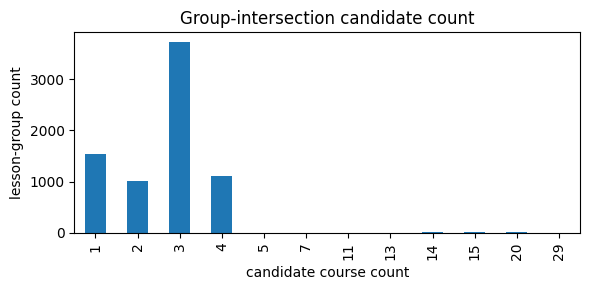

In [18]:
ul_group_base = ul_base[["user_id", "lesson_id", "group_id", "users_course_id"]].dropna(subset=["lesson_id", "group_id"]).drop_duplicates()
group_members = ul_group_base[["lesson_id", "group_id", "user_id"]].drop_duplicates()
group_sizes = group_members.groupby(["lesson_id", "group_id"])["user_id"].nunique().rename("group_size").reset_index()
group_member_courses = group_members.merge(uc_pairs[["user_id", "course_id"]], on="user_id", how="left").dropna(subset=["course_id"])
group_course_support = group_member_courses.groupby(["lesson_id", "group_id", "course_id"])["user_id"].nunique().rename("course_support").reset_index().merge(group_sizes, on=["lesson_id", "group_id"], how="left")
group_course_intersection = group_course_support.loc[group_course_support["course_support"].eq(group_course_support["group_size"]), ["lesson_id", "group_id", "course_id"]].copy()
ul_group_candidates = ul_group_base.merge(group_course_intersection, on=["lesson_id", "group_id"], how="left").dropna(subset=["course_id"])
user_ucid_group_count = ul_group_base.groupby(["user_id", "users_course_id"]).size().rename("pair_group_count").reset_index()
group_edges = ul_group_candidates.drop_duplicates(["user_id", "users_course_id", "lesson_id", "group_id", "course_id"]).groupby(["user_id", "users_course_id", "course_id"]).size().rename("support").reset_index().merge(user_ucid_group_count, on=["user_id", "users_course_id"], how="left").query("support == pair_group_count")[["user_id", "course_id", "users_course_id"]].drop_duplicates()
group_signal_audit_AGENTS = pd.DataFrame([{"metric": "lesson_group_count", "value": group_sizes.shape[0]}, {"metric": "lesson_groups_with_intersection", "value": group_course_intersection[["lesson_id", "group_id"]].drop_duplicates().shape[0]}, {"metric": "group_candidate_edges", "value": len(group_edges)}, {"metric": "group_candidate_user_ucid", "value": group_edges[["user_id", "users_course_id"]].drop_duplicates().shape[0]}])
display(group_signal_audit_AGENTS)
plot_bar(group_course_intersection.groupby(["lesson_id", "group_id"])["course_id"].nunique().value_counts().sort_index().head(20), "Group-intersection candidate count", "candidate course count", "lesson-group count")


### 5.4 Global uniqueness and conflict removal

A mapping is accepted only if it is one-to-one inside a method and remains conflict-free after method union.


In [19]:
def force_unique(edges: pd.DataFrame) -> pd.DataFrame:
    keys = ["user_id", "course_id", "users_course_id"]
    edges = edges[keys].drop_duplicates().copy()
    if edges.empty:
        return edges
    c1 = edges.groupby(["user_id", "users_course_id"])["course_id"].nunique().rename("course_candidates").reset_index()
    c2 = edges.groupby(["user_id", "course_id"])["users_course_id"].nunique().rename("ucid_candidates").reset_index()
    tmp = edges.merge(c1, on=["user_id", "users_course_id"]).merge(c2, on=["user_id", "course_id"])
    return tmp.loc[tmp["course_candidates"].eq(1) & tmp["ucid_candidates"].eq(1), keys].drop_duplicates()

evidence_parts = []
for label, col in [("points", "points_match"), ("lesson_count", "lesson_count_match"), ("access_date", "access_date_match")]:
    part = candidate_cross.loc[candidate_cross[col], ["user_id", "course_id", "users_course_id"]].drop_duplicates().copy()
    part["evidence"] = label
    evidence_parts.append(part)
group_part = group_edges.copy(); group_part["evidence"] = "group_intersection"; evidence_parts.append(group_part)
evidence_long = pd.concat(evidence_parts, ignore_index=True).drop_duplicates()
edge_evidence = evidence_long.groupby(["user_id", "course_id", "users_course_id"])["evidence"].agg(lambda s: "|".join(sorted(set(s)))).reset_index()
edge_evidence["evidence_count"] = edge_evidence["evidence"].str.count(r"\|") + 1
method_edges = {"points_unique": force_unique(edge_evidence.loc[edge_evidence["evidence"].str.contains("points", regex=False)]), "date_unique": force_unique(edge_evidence.loc[edge_evidence["evidence"].str.contains("access_date", regex=False)]), "group_unique": force_unique(edge_evidence.loc[edge_evidence["evidence"].str.contains("group_intersection", regex=False)]), "evidence2_unique": force_unique(edge_evidence.loc[edge_evidence["evidence_count"].ge(2)])}
user_course_count = uc_pairs.groupby("user_id")["course_id"].nunique().rename("course_count").reset_index()
user_ucid_count = all_user_ucid.groupby("user_id")["users_course_id"].nunique().rename("observed_users_course_id_count").reset_index()
method_edges["user_singleton"] = user_course_count.merge(user_ucid_count, on="user_id", how="inner").query("course_count == 1 and observed_users_course_id_count == 1")[["user_id"]].merge(uc_pairs[["user_id", "course_id"]], on="user_id").merge(all_user_ucid, on="user_id")[["user_id", "course_id", "users_course_id"]].drop_duplicates()
method_union = pd.concat([df.assign(resolution_method=name) for name, df in method_edges.items()], ignore_index=True).drop_duplicates()
edge_methods = method_union.groupby(["user_id", "course_id", "users_course_id"])["resolution_method"].agg(lambda s: "|".join(sorted(set(s)))).reset_index()
conflict_user_course = edge_methods.groupby(["user_id", "course_id"])["users_course_id"].nunique().rename("users_course_id_count").reset_index().query("users_course_id_count > 1")
conflict_user_ucid = edge_methods.groupby(["user_id", "users_course_id"])["course_id"].nunique().rename("course_id_count").reset_index().query("course_id_count > 1")
clean_mapping = edge_methods.merge(conflict_user_course[["user_id", "course_id"]].assign(_conflict_uc=1), on=["user_id", "course_id"], how="left").merge(conflict_user_ucid[["user_id", "users_course_id"]].assign(_conflict_id=1), on=["user_id", "users_course_id"], how="left")
clean_mapping = clean_mapping.loc[clean_mapping["_conflict_uc"].isna() & clean_mapping["_conflict_id"].isna()].drop(columns=["_conflict_uc", "_conflict_id"])
method_acceptance_audit_AGENTS = pd.DataFrame([{"method": k, "accepted_edges_before_global_conflict_check": len(v)} for k, v in method_edges.items()]).sort_values("accepted_edges_before_global_conflict_check", ascending=False)
display(method_acceptance_audit_AGENTS)
display(conflict_user_course)
display(conflict_user_ucid)


,method,accepted_edges_before_global_conflict_check
3,evidence2_unique,199691
0,points_unique,195844
1,date_unique,99011
2,group_unique,51592
4,user_singleton,7390


,user_id,course_id,users_course_id_count


,user_id,users_course_id,course_id_count
3393,671864,463215,2
7038,678685,476135,2


### 5.5 Final mapping and resolution audit

The final mapping is a left join to all base `(user_id, course_id)` pairs. Unresolved rows are kept or dropped later based on `UNRESOLVED_MODE`.


,metric,value
0,total_student_user_course_pairs,267206.00000
1,resolved_pairs,207977.00000
2,unresolved_pairs,59229.00000
3,resolved_share,0.77834
4,conflict_user_course_pairs_removed,0.00000
5,conflict_user_ucid_pairs_removed,2.00000
6,observed_student_users_course_id,208685.00000


,reason_bucket,pair_count
0,ambiguous_or_no_reliable_signal,35889
1,no_observed_users_course_id_for_user,23340


,course_id,unresolved_pair_count
9,763,27631
17,836,9708
14,770,6225
77,50000592,4470
78,170000688,2642
71,1061,2069
73,1096,1908
15,771,918
61,1033,633
72,1062,409


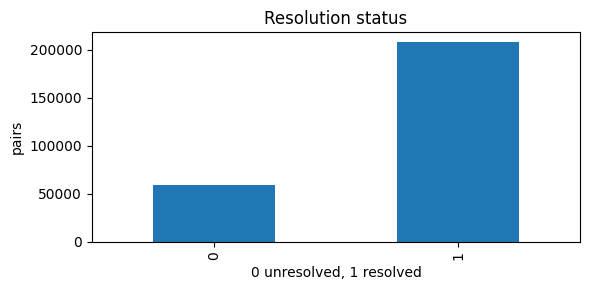

In [20]:
resolution_mapping_AGENTS = uc_pairs[["user_id", "course_id"]].merge(clean_mapping, on=["user_id", "course_id"], how="left").sort_values(["user_id", "course_id"]).reset_index(drop=True)
resolution_mapping_AGENTS["users_course_id"] = pd.to_numeric(resolution_mapping_AGENTS["users_course_id"], errors="coerce").astype("Int64")
resolution_mapping_AGENTS["users_course_id_resolved_flag"] = resolution_mapping_AGENTS["users_course_id"].notna().astype("Int8")
resolution_mapping_AGENTS["unresolved_handling_mode"] = UNRESOLVED_MODE
resolution_mapping_AGENTS["maybe_dropped_for_resolution_flag"] = ((UNRESOLVED_MODE == "drop") & resolution_mapping_AGENTS["users_course_id"].isna()).astype("Int8")
key_resolution_audit_AGENTS = pd.DataFrame([{"metric": "total_student_user_course_pairs", "value": len(resolution_mapping_AGENTS)}, {"metric": "resolved_pairs", "value": int(resolution_mapping_AGENTS["users_course_id_resolved_flag"].sum())}, {"metric": "unresolved_pairs", "value": int(resolution_mapping_AGENTS["users_course_id"].isna().sum())}, {"metric": "resolved_share", "value": float(resolution_mapping_AGENTS["users_course_id_resolved_flag"].mean())}, {"metric": "conflict_user_course_pairs_removed", "value": len(conflict_user_course)}, {"metric": "conflict_user_ucid_pairs_removed", "value": len(conflict_user_ucid)}, {"metric": "observed_student_users_course_id", "value": all_user_ucid["users_course_id"].nunique()}])
unresolved_reason_AGENTS = resolution_mapping_AGENTS.loc[resolution_mapping_AGENTS["users_course_id"].isna(), ["user_id", "course_id"]].merge(user_ucid_count, on="user_id", how="left")
unresolved_reason_AGENTS["reason_bucket"] = np.where(unresolved_reason_AGENTS["observed_users_course_id_count"].isna(), "no_observed_users_course_id_for_user", "ambiguous_or_no_reliable_signal")
unresolved_reason_summary_AGENTS = unresolved_reason_AGENTS["reason_bucket"].value_counts().rename_axis("reason_bucket").reset_index(name="pair_count")
unresolved_course_summary_AGENTS = unresolved_reason_AGENTS.groupby("course_id").size().rename("unresolved_pair_count").reset_index().sort_values("unresolved_pair_count", ascending=False)
display(key_resolution_audit_AGENTS)
display(unresolved_reason_summary_AGENTS)
display(unresolved_course_summary_AGENTS.head(25))
plot_bar(resolution_mapping_AGENTS["users_course_id_resolved_flag"].value_counts().sort_index(), "Resolution status", "0 unresolved, 1 resolved", "pairs")


## 6. Resolution coverage and base entity

This block proves that the restored key gives high coverage for `user_lessons` and `wk_users_courses_actions`. `user_access_histories` total coverage is lower because the table has ids outside observed student activity scope.


,table,unique_ids_total,covered_unique_ids_total,covered_unique_share_total,rows_total,covered_rows_total,covered_row_share_total,observed_scope_unique_ids,observed_scope_covered_unique_ids,observed_scope_covered_unique_share
0,user_lessons,208672,207971,0.996641,3008595,3002233,0.997885,208672,207971,0.996641
1,wk_users_courses_actions,208565,207883,0.996730,12633684,12601087,0.997420,208565,207883,0.996730
2,user_access_histories,290784,207976,0.715225,667124,568901,0.852767,208646,207976,0.996789


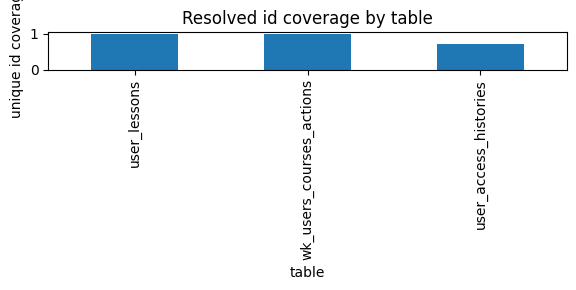

,metric,value
0,base_rows_after_policy,267206.00000
1,duplicate_user_course,0.00000
2,resolved_share_after_policy,0.77834


In [21]:
resolved_ids = set(resolution_mapping_AGENTS["users_course_id"].dropna().astype("int64"))
observed_student_ucids = set(all_user_ucid["users_course_id"].dropna().astype("int64"))
def coverage_for_users_course_id(table_name: str, df: pd.DataFrame) -> dict:
    ids_total = set(df["users_course_id"].dropna().astype("int64"))
    rows_total = len(df)
    covered_rows = int(df["users_course_id"].isin(resolved_ids).sum())
    observed_ids = ids_total & observed_student_ucids
    return {"table": table_name, "unique_ids_total": len(ids_total), "covered_unique_ids_total": len(ids_total & resolved_ids), "covered_unique_share_total": len(ids_total & resolved_ids) / len(ids_total) if ids_total else 0.0, "rows_total": rows_total, "covered_rows_total": covered_rows, "covered_row_share_total": covered_rows / rows_total if rows_total else 0.0, "observed_scope_unique_ids": len(observed_ids), "observed_scope_covered_unique_ids": len(observed_ids & resolved_ids), "observed_scope_covered_unique_share": len(observed_ids & resolved_ids) / len(observed_ids) if observed_ids else 0.0}
resolution_table_coverage_AGENTS = pd.DataFrame([coverage_for_users_course_id("user_lessons", dfs["user_lessons"].rename(columns={"user_lesson_row_id":"unused"})), coverage_for_users_course_id("wk_users_courses_actions", dfs["wk_users_courses_actions"]), coverage_for_users_course_id("user_access_histories", dfs["user_access_histories"])])
display(resolution_table_coverage_AGENTS)
plot_bar(resolution_table_coverage_AGENTS.set_index("table")["covered_unique_share_total"], "Resolved id coverage by table", "table", "unique id coverage")
base_entity_AGENTS = dfs["users_courses"].dropna(subset=["user_id", "course_id"]).drop_duplicates(subset=["user_id", "course_id"]).merge(resolution_mapping_AGENTS, on=["user_id", "course_id"], how="left", validate="one_to_one")
if UNRESOLVED_MODE == "drop":
    base_entity_AGENTS = base_entity_AGENTS.loc[base_entity_AGENTS["users_course_id_resolved_flag"].eq(1)].copy()
base_entity_audit_AGENTS = pd.DataFrame([{"metric": "base_rows_after_policy", "value": len(base_entity_AGENTS)}, {"metric": "duplicate_user_course", "value": int(base_entity_AGENTS.duplicated(["user_id", "course_id"]).sum())}, {"metric": "resolved_share_after_policy", "value": float(base_entity_AGENTS["users_course_id_resolved_flag"].mean())}])
display(base_entity_audit_AGENTS)


## 7. Feature engineering by source

Each feature block is aggregated to a safe join grain: `course_id`, `users_course_id`, or `user_id`. Raw ids are not used as predictive features.


### 7.1 Course-level features from `lessons`

This block keeps compact course structure features. It does not replace `users_courses` course-level fields because source EDA showed mismatches.


In [22]:
lessons = dfs["lessons"].copy()
lessons_agg_AGENTS = lessons.groupby("course_id").agg(course_lessons_count=("course_id", "size"), course_task_expected_share=("task_expected", "mean"), course_conspect_expected_share=("conspect_expected", "mean"), course_survival_training_share=("wk_survival_training_expected", "mean"), course_scratch_enabled_share=("wk_scratch_playground_enabled", "mean"), course_attendance_tracking_share=("wk_attendance_tracking_enabled", "mean"), course_lessons_wk_max_points_sum=("wk_max_points", "sum"), course_lessons_wk_task_count_sum=("wk_task_count", "sum"), course_video_duration_sum=("wk_video_duration", "sum"), course_video_duration_mean=("wk_video_duration", "mean")).reset_index()
display_head(lessons_agg_AGENTS)


,course_id,course_lessons_count,course_task_expected_share,course_conspect_expected_share,course_survival_training_share,course_scratch_enabled_share,course_attendance_tracking_share,course_lessons_wk_max_points_sum,course_lessons_wk_task_count_sum,course_video_duration_sum,course_video_duration_mean
0,754,21,0.952381,0.0,0.0,0.0,0.0,71.0,71.0,20.0,1.000000
1,755,1,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.0,NaN
2,756,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,25.0,12.500000
3,757,24,0.0,0.125,0.0,0.0,0.0,0.0,0.0,18.0,9.000000
4,758,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
5,759,31,0.903226,0.903226,0.0,0.0,0.0,66.0,64.0,252.0,8.689655
6,760,24,0.708333,0.333333,0.0,0.0,0.0,109.0,100.0,0.0,NaN
7,761,31,0.903226,0.903226,0.0,0.0,0.0,66.0,64.0,252.0,8.689655
8,762,1,0.0,0.0,0.0,0.0,0.0,3.0,1.0,0.0,NaN
9,763,5,0.4,0.4,0.0,0.0,0.0,4.0,4.0,20.0,6.666667


### 7.2 Lesson progress features from `user_lessons`

These features are course-specific after the restored key because they are aggregated by `users_course_id`.


In [23]:
ul = dfs["user_lessons"].copy()
user_lessons_features_AGENTS = ul.groupby("users_course_id").agg(ul_rows=("lesson_id", "size"), ul_lesson_nunique=("lesson_id", "nunique"), ul_group_nunique=("group_id", "nunique"), ul_video_visited_sum=("video_visited", "sum"), ul_video_viewed_sum=("video_viewed", "sum"), ul_translation_visited_sum=("translation_visited", "sum"), ul_solved_lessons_sum=("solved", "sum"), ul_solved_tasks_sum=("solved_tasks_count", "sum"), ul_wk_solved_task_sum=("wk_solved_task_count", "sum"), ul_points_sum=("wk_points", "sum"), ul_points_mean=("wk_points", "mean")).reset_index()
user_lessons_features_AGENTS["ul_video_visited_share"] = safe_div(user_lessons_features_AGENTS["ul_video_visited_sum"], user_lessons_features_AGENTS["ul_rows"])
user_lessons_features_AGENTS["ul_translation_visited_share"] = safe_div(user_lessons_features_AGENTS["ul_translation_visited_sum"], user_lessons_features_AGENTS["ul_rows"])
user_lessons_features_AGENTS["ul_solved_lesson_share"] = safe_div(user_lessons_features_AGENTS["ul_solved_lessons_sum"], user_lessons_features_AGENTS["ul_rows"])
display_head(user_lessons_features_AGENTS)


,users_course_id,ul_rows,ul_lesson_nunique,ul_group_nunique,ul_video_visited_sum,ul_video_viewed_sum,ul_translation_visited_sum,ul_solved_lessons_sum,ul_solved_tasks_sum,ul_wk_solved_task_sum,ul_points_sum,ul_points_mean,ul_video_visited_share,ul_translation_visited_share,ul_solved_lesson_share
0,449077,5,5,5,5,0,0,0,0,0.0,0.0,NaN,1.0,0.0,0.000000
1,449101,1,1,1,1,0,0,0,0,0.0,0.0,NaN,1.0,0.0,0.000000
2,449128,5,5,5,4,0,0,1,10,10.0,6.0,3.0,0.8,0.0,0.200000
3,449138,4,4,4,4,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.000000
4,449139,2,2,2,2,0,0,0,0,0.0,0.0,NaN,1.0,0.0,0.000000
5,449154,1,1,1,1,0,0,0,0,0.0,0.0,NaN,1.0,0.0,0.000000
6,449161,1,1,1,1,0,0,0,0,0.0,0.0,NaN,1.0,0.0,0.000000
7,449164,1,1,1,1,0,0,0,0,0.0,0.0,NaN,1.0,0.0,0.000000
8,449166,1,1,1,1,0,0,0,0,0.0,0.0,NaN,1.0,0.0,0.000000
9,449171,3,3,3,3,0,0,1,2,2.0,1.5,1.5,1.0,0.0,0.333333


### 7.3 Course action temporal features from `wk_users_courses_actions`

This block improves the weaker single aggregate from the old EDA by adding action diversity, first/last action, active days, activity span and max/mean gaps.


In [24]:
wka = dfs["wk_users_courses_actions"].dropna(subset=["users_course_id"]).copy()
wka_base_agg = wka.groupby("users_course_id").agg(wka_event_count=("action_clean", "size"), wka_action_nunique=("action_clean", "nunique"), wka_lesson_nunique=("lesson_id", "nunique"), wka_first_action_at=("created_at", "min"), wka_last_action_at=("created_at", "max"), wka_active_days=("created_at", lambda s: s.dt.normalize().nunique())).reset_index()
wka_counts = pd.crosstab(wka["users_course_id"], wka["action_clean"]).add_prefix("wka_action_count_").reset_index()
wka_features_AGENTS = wka_base_agg.merge(wka_counts, on="users_course_id", how="left", validate="one_to_one")
wka_features_AGENTS["wka_activity_span_days"] = (wka_features_AGENTS["wka_last_action_at"] - wka_features_AGENTS["wka_first_action_at"]).dt.days
for col in [c for c in wka_features_AGENTS.columns if c.startswith("wka_action_count_")]:
    wka_features_AGENTS[col.replace("wka_action_count_", "wka_action_share_")] = safe_div(wka_features_AGENTS[col], wka_features_AGENTS["wka_event_count"])
wka_sorted = wka.dropna(subset=["created_at"]).sort_values(["users_course_id", "created_at"])
wka_sorted["wka_gap_days"] = wka_sorted.groupby("users_course_id")["created_at"].diff().dt.total_seconds() / 86400
wka_gap_features = wka_sorted.groupby("users_course_id").agg(wka_gap_days_mean=("wka_gap_days", "mean"), wka_gap_days_max=("wka_gap_days", "max")).reset_index()
wka_features_AGENTS = wka_features_AGENTS.merge(wka_gap_features, on="users_course_id", how="left", validate="one_to_one")
display_head(wka_features_AGENTS)


,users_course_id,wka_event_count,wka_action_nunique,wka_lesson_nunique,wka_first_action_at,wka_last_action_at,wka_active_days,wka_action_count_scratch_playground_visited,wka_action_count_start_training,wka_action_count_user_answer,wka_action_count_visit_preparation_material,wka_action_count_visit_translation,wka_action_count_visit_video,wka_activity_span_days,wka_action_share_scratch_playground_visited,wka_action_share_start_training,wka_action_share_user_answer,wka_action_share_visit_preparation_material,wka_action_share_visit_translation,wka_action_share_visit_video,wka_gap_days_mean,wka_gap_days_max
0,449077,5,1,0,2025-02-17 11:35:00,2025-02-17 13:22:00,1,0,0,0,0,0,5,0,0.0,0.000000,0.000000,0.000,0.0,1.000000,0.018576,0.073611
1,449101,1,1,0,2025-04-24 15:10:00,2025-04-24 15:10:00,1,0,0,0,0,0,1,0,0.0,0.000000,0.000000,0.000,0.0,1.000000,NaN,NaN
2,449128,6,3,0,2025-02-19 13:04:00,2025-03-30 18:05:00,2,0,1,1,0,0,4,39,0.0,0.166667,0.166667,0.000,0.0,0.666667,7.841806,39.052083
3,449138,8,3,1,2025-03-12 15:45:00,2025-03-12 16:09:00,1,0,0,3,1,0,4,0,0.0,0.000000,0.375000,0.125,0.0,0.500000,0.002381,0.013194
4,449139,2,1,0,2025-02-19 15:59:00,2025-02-19 15:59:00,1,0,0,0,0,0,2,0,0.0,0.000000,0.000000,0.000,0.0,1.000000,0.000000,0.000000
5,449154,1,1,0,2025-02-19 17:45:00,2025-02-19 17:45:00,1,0,0,0,0,0,1,0,0.0,0.000000,0.000000,0.000,0.0,1.000000,NaN,NaN
6,449161,2,2,1,2025-02-19 18:00:00,2025-02-19 18:00:00,1,0,0,0,1,0,1,0,0.0,0.000000,0.000000,0.500,0.0,0.500000,0.000000,0.000000
7,449164,1,1,0,2025-02-19 18:04:00,2025-02-19 18:04:00,1,0,0,0,0,0,1,0,0.0,0.000000,0.000000,0.000,0.0,1.000000,NaN,NaN
8,449166,1,1,0,2025-02-19 18:04:00,2025-02-19 18:04:00,1,0,0,0,0,0,1,0,0.0,0.000000,0.000000,0.000,0.0,1.000000,NaN,NaN
9,449171,5,2,0,2025-02-19 18:40:00,2025-02-19 18:54:00,1,0,0,2,0,0,3,0,0.0,0.000000,0.400000,0.000,0.0,0.600000,0.002431,0.006250


### 7.4 Access features from `user_access_histories`

Access windows can explain non-standard completion and churn patterns. This block is joined by restored `users_course_id`.


In [25]:
access = dfs["user_access_histories"].copy()
access_agg_AGENTS = access.groupby("users_course_id").agg(access_rows=("users_course_id", "size"), access_started_min=("access_started_at", "min"), access_started_max=("access_started_at", "max"), access_expired_min=("access_expired_at", "min"), access_expired_max=("access_expired_at", "max"), access_interval_days_sum=("access_interval_days", "sum"), access_interval_days_max=("access_interval_days", "max"), access_activator_nunique=("activator_clean", "nunique")).reset_index()
access_counts = pd.crosstab(access["users_course_id"], access["activator_clean"]).add_prefix("access_activator_count_").reset_index()
access_features_AGENTS = access_agg_AGENTS.merge(access_counts, on="users_course_id", how="left", validate="one_to_one")
access_features_AGENTS["access_window_days"] = (access_features_AGENTS["access_expired_max"] - access_features_AGENTS["access_started_min"]).dt.days
display_head(access_features_AGENTS)


,users_course_id,access_rows,access_started_min,access_started_max,access_expired_min,access_expired_max,access_interval_days_sum,access_interval_days_max,access_activator_nunique,access_activator_count_changeaccessdurationactivator,access_activator_count_monthpremiumaccessactivator,access_activator_count_premiumaccessactivator,access_activator_count_revokeaccessactivator,access_activator_count_standardaccessactivator,access_window_days
0,449032,1,2025-02-07,2025-02-07,2025-08-31,2025-08-31,205,205,1,0,0,1,0,0,205
1,449033,1,2025-02-11,2025-02-11,2025-06-30,2025-06-30,139,139,1,0,0,1,0,0,139
2,449034,1,2025-02-17,2025-02-17,2025-06-30,2025-06-30,133,133,1,0,0,1,0,0,133
3,449035,1,2025-02-17,2025-02-17,2025-06-30,2025-06-30,133,133,1,0,0,1,0,0,133
4,449036,1,2025-02-17,2025-02-17,2025-06-30,2025-06-30,133,133,1,0,0,1,0,0,133
5,449037,1,2025-02-17,2025-02-17,2025-06-30,2025-06-30,133,133,1,0,0,1,0,0,133
6,449038,2,2025-02-17,2025-02-17,2025-02-16,2025-06-30,132,133,2,0,0,1,1,0,133
7,449039,1,2025-02-17,2025-02-17,2025-06-30,2025-06-30,133,133,1,0,0,1,0,0,133
8,449040,2,2025-02-17,2025-02-17,2025-02-16,2025-06-30,132,133,2,0,0,1,1,0,133
9,449041,1,2025-02-17,2025-02-17,2025-06-30,2025-06-30,133,133,1,0,0,1,0,0,133


### 7.5 Auxiliary activity features from `user_activity_histories`

This table is not a replacement for WKA. It is joined through `user_lesson_id -> user_lessons.user_lesson_row_id` and used only as auxiliary activity evidence with explicit bridge audit.


In [26]:
ul_bridge = dfs["user_lessons"][["user_lesson_row_id", "users_course_id"]].dropna().drop_duplicates(subset=["user_lesson_row_id"])
uahist = dfs["user_activity_histories"].copy()
uahist_joined = uahist.merge(ul_bridge, left_on="user_lesson_id", right_on="user_lesson_row_id", how="left")
user_activity_bridge_audit_AGENTS = pd.DataFrame([{"metric": "uahist_rows", "value": len(uahist_joined)}, {"metric": "uahist_rows_joined_to_user_lessons", "value": int(uahist_joined["users_course_id"].notna().sum())}, {"metric": "uahist_joined_row_share", "value": float(uahist_joined["users_course_id"].notna().mean())}, {"metric": "uahist_unique_user_lesson_id", "value": uahist["user_lesson_id"].nunique()}])
uahist_joined = uahist_joined.dropna(subset=["users_course_id"]).copy()
uahist_base = uahist_joined.groupby("users_course_id").agg(uahist_event_count=("action_clean", "size"), uahist_action_nunique=("action_clean", "nunique"), uahist_first_at=("created_at", "min"), uahist_last_at=("created_at", "max")).reset_index()
uahist_counts = pd.crosstab(uahist_joined["users_course_id"], uahist_joined["action_clean"]).add_prefix("uahist_action_count_").reset_index()
user_activity_features_AGENTS = uahist_base.merge(uahist_counts, on="users_course_id", how="left", validate="one_to_one")
display(user_activity_bridge_audit_AGENTS)
display_head(user_activity_features_AGENTS)


,metric,value
0,uahist_rows,3.031137e+06
1,uahist_rows_joined_to_user_lessons,2.773902e+06
2,uahist_joined_row_share,9.151358e-01
3,uahist_unique_user_lesson_id,2.546319e+06


,users_course_id,uahist_event_count,uahist_action_nunique,uahist_first_at,uahist_last_at,uahist_action_count_show_conspect,uahist_action_count_visit_translation,uahist_action_count_visit_video
0,449077,10,2,2020-11-25 13:36:00,2021-05-24 12:56:00,0,9,1
1,449208,2,1,2020-11-27 13:28:00,2020-11-27 13:45:00,0,2,0
2,449226,2,1,2021-01-19 08:08:00,2021-01-19 08:31:00,0,0,2
3,449255,1,1,2020-12-04 16:33:00,2020-12-04 16:33:00,0,0,1
4,449297,2,1,2020-12-04 16:26:00,2020-12-04 16:28:00,0,2,0
5,449347,1,1,2022-04-26 11:03:00,2022-04-26 11:03:00,0,0,1
6,449495,9,2,2020-12-10 05:33:00,2021-05-12 08:53:00,6,0,3
7,449581,14,1,2020-12-09 08:45:00,2021-07-27 05:40:00,0,0,14
8,449589,11,2,2020-12-09 12:21:00,2022-02-26 09:32:00,7,0,4
9,449590,1,1,2024-01-26 08:33:00,2024-01-26 08:33:00,0,0,1


### 7.6 User profile features from `users`

These are user-level enrichment features. They are not course-specific but can help model general engagement background.


In [27]:
users = dfs["users"].copy()
users_features_AGENTS = users[["user_id", "sign_in_count", "grade_id", "timezone", "d_wk_school_id", "d_wk_municipal_id", "d_wk_region_id", "wk_gender", "user_subscribed_flag"]].drop_duplicates(subset=["user_id"]).copy()
display_head(users_features_AGENTS)


,user_id,sign_in_count,grade_id,timezone,d_wk_school_id,d_wk_municipal_id,d_wk_region_id,wk_gender,user_subscribed_flag
0,675765,3,3003,Europe/Moscow,116371,96112,93938,2.0,1
1,679040,5,3007,Europe/Moscow,111130,95522,93512,2.0,1
2,679200,3,3006,Europe/Moscow,109819,94362,93594,1.0,1
3,678069,2,3009,Europe/Moscow,141024,93461,93460,2.0,1
4,693126,6,3010,Asia/Yekaterinburg,144581,144580,144579,NaN,1
9,665750,3,3012,Europe/Moscow,144476,144475,144474,1.0,0
12,665740,21,3012,Europe/Moscow,93422,93421,93420,NaN,0
13,665741,2,3012,Europe/Moscow,144476,144475,144474,1.0,0
14,666098,6,3007,Europe/Moscow,113387,95308,93512,1.0,1
16,725822,27,3010,Europe/Moscow,283069,239103,238711,NaN,1


### 7.7 Training features from `user_trainings`

Training records have no validated course key in raw data, so this block is user-level. It is especially relevant for the success proxy because marks `>= 4` are part of the business definition.


In [28]:
train = dfs["user_trainings"].copy()
train_agg = train.groupby("user_id").agg(train_rows=("training_id", "size"), train_unique_trainings=("training_id", "nunique"), train_solved_tasks_sum=("solved_tasks_count", "sum"), train_earned_points_sum=("earned_points", "sum"), train_submitted_answers_sum=("submitted_answers_count", "sum"), train_attempts_sum=("attempts", "sum"), train_mark_mean=("mark", "mean"), train_mark_ge4_count=("mark_ge4_flag", "sum"), train_first_started_at=("started_at", "min"), train_last_finished_at=("finished_at", "max"), train_duration_min_mean=("training_duration_min", "mean")).reset_index()
train_type_counts = pd.crosstab(train["user_id"], train["type_clean"]).add_prefix("train_type_count_").reset_index()
train_state_counts = pd.crosstab(train["user_id"], train["state_clean"]).add_prefix("train_state_count_").reset_index()
training_features_AGENTS = train_agg.merge(train_type_counts, on="user_id", how="left", validate="one_to_one").merge(train_state_counts, on="user_id", how="left", validate="one_to_one")
display_head(training_features_AGENTS)


,user_id,train_rows,train_unique_trainings,train_solved_tasks_sum,train_earned_points_sum,train_submitted_answers_sum,train_attempts_sum,train_mark_mean,train_mark_ge4_count,train_first_started_at,train_last_finished_at,train_duration_min_mean,train_type_count_lessontraining,train_type_count_olympiadtraining,train_type_count_regulartraining,train_state_count_checked,train_state_count_started
0,665750,1,1,0,0.0,0,1,NaN,0,2025-02-17 08:47:00,NaT,NaN,0,0,1,0,1
1,665768,1,1,0,0.0,0,1,NaN,0,2025-02-17 11:34:00,NaT,NaN,0,0,1,0,1
2,665778,1,1,0,0.0,0,1,NaN,0,2025-02-18 06:52:00,NaT,NaN,0,0,1,0,1
3,665791,1,1,10,6.0,10,1,4.000000,1,2025-02-19 13:04:00,2025-02-19 13:08:00,4.000000,1,0,0,1,0
4,665795,1,1,0,0.0,0,1,NaN,0,2025-02-19 15:57:00,NaT,NaN,0,0,1,0,1
5,665800,1,1,0,0.0,0,1,NaN,0,2025-10-09 16:01:00,NaT,NaN,0,0,1,0,1
6,665809,1,1,0,0.0,0,1,NaN,0,2025-02-25 15:14:00,NaT,NaN,0,0,1,0,1
7,665811,1,1,0,0.0,0,1,NaN,0,2025-10-09 15:54:00,NaT,NaN,0,0,1,0,1
8,665827,2,2,10,8.0,10,2,4.000000,1,2025-02-20 07:12:00,2025-02-20 07:28:00,16.000000,1,0,1,1,1
9,665845,4,4,18,17.0,18,4,4.666667,3,2025-02-20 13:16:00,2025-03-30 04:11:00,3.333333,3,0,1,3,1


### 7.8 Media session features from `wk_media_view_sessions`

Media features are user-level only. They support engagement hypotheses but should not be interpreted as exact course-level behavior.


In [29]:
media = dfs["wk_media_view_sessions"].copy()
media_agg = media.groupby("user_id").agg(media_sessions=("resource_type", "size"), media_segments_total_sum=("segments_total", "sum"), media_segments_viewed_sum=("viewed_segments_count", "sum"), media_view_ratio_mean=("media_view_ratio_row", "mean"), media_first_started_at=("started_at", "min"), media_last_started_at=("started_at", "max"), media_kind_nunique=("kind_clean", "nunique")).reset_index()
media_kind_counts = pd.crosstab(media["user_id"], media["kind_clean"]).add_prefix("media_kind_count_").reset_index()
media_features_AGENTS = media_agg.merge(media_kind_counts, on="user_id", how="left", validate="one_to_one")
media_features_AGENTS["media_viewed_segments_share"] = safe_div(media_features_AGENTS["media_segments_viewed_sum"], media_features_AGENTS["media_segments_total_sum"])
display_head(media_features_AGENTS)


,user_id,media_sessions,media_segments_total_sum,media_segments_viewed_sum,media_view_ratio_mean,media_first_started_at,media_last_started_at,media_kind_nunique,media_kind_count_kinescope,media_kind_count_ulms_live,media_kind_count_ulms_vod,media_viewed_segments_share
0,665854,1,19,4,0.210526,2025-06-16 17:44:00,2025-06-16 17:44:00,1,1,0,0,0.210526
1,666074,1,23,12,0.521739,2025-06-04 02:00:00,2025-06-04 02:00:00,1,1,0,0,0.521739
2,666120,7,142,75,0.534077,2025-06-11 10:39:00,2025-06-19 11:50:00,1,7,0,0,0.528169
3,666226,24,514,249,0.495526,2025-06-10 06:20:00,2025-06-15 09:40:00,1,24,0,0,0.484436
4,666256,3,20,20,1.000000,2025-06-06 06:17:00,2025-06-10 04:19:00,1,3,0,0,1.000000
5,666434,16,388,107,0.297019,2025-06-04 11:41:00,2025-06-13 13:15:00,1,16,0,0,0.275773
6,666452,4,82,22,0.276250,2025-06-06 07:19:00,2025-06-16 07:28:00,1,4,0,0,0.268293
7,666518,9,187,80,0.439131,2025-06-15 09:39:00,2025-06-22 11:20:00,1,9,0,0,0.427807
8,666582,1,20,6,0.300000,2025-05-30 06:41:00,2025-05-30 06:41:00,1,1,0,0,0.300000
9,666878,27,564,226,0.391239,2025-05-29 07:28:00,2025-06-10 15:24:00,1,27,0,0,0.400709


### 7.9 Award features from badges

Awards are user-level motivation proxies. The old EDA noted that some badge types may be mutually exclusive; here we keep compact counts and levels.


In [30]:
award_ref = dfs["award_badges"]
award_events = dfs["user_award_badges"].merge(award_ref[["award_badge_id", "level", "quota", "special", "award_name_clean"]], on="award_badge_id", how="left")
award_agg = award_events.groupby("user_id").agg(badge_rows=("award_badge_id", "size"), badge_unique_count=("award_badge_id", "nunique"), badge_level_max=("level", "max"), badge_level_mean=("level", "mean"), badge_special_sum=("special", "sum"), badge_first_at=("created_at", "min"), badge_last_at=("created_at", "max")).reset_index()
award_name_counts = pd.crosstab(award_events["user_id"], award_events["award_name_clean"]).add_prefix("badge_name_count_").reset_index()
award_features_AGENTS = award_agg.merge(award_name_counts, on="user_id", how="left", validate="one_to_one")
display_head(award_features_AGENTS)


,user_id,badge_rows,badge_unique_count,badge_level_max,badge_level_mean,badge_special_sum,badge_first_at,badge_last_at,badge_name_count_solving
0,663004,2,2,3.0,2.5,0,2023-11-14 12:37:00,2023-11-28 12:51:00,2
1,663005,2,2,3.0,2.5,0,2023-10-03 12:53:00,2023-11-14 12:35:00,2
2,663006,1,1,2.0,2.0,0,2023-10-03 12:54:00,2023-10-03 12:54:00,1
3,663007,2,2,3.0,2.5,0,2023-11-07 12:51:00,2024-02-09 20:07:00,2
4,663009,2,2,3.0,2.5,0,2023-12-13 06:54:00,2023-12-13 07:03:00,2
5,663011,1,1,2.0,2.0,0,2023-10-17 12:44:00,2023-10-17 12:44:00,1
6,663012,1,1,2.0,2.0,0,2023-10-12 09:23:00,2023-10-12 09:23:00,1
7,663017,1,1,2.0,2.0,0,2023-11-16 12:58:00,2023-11-16 12:58:00,1
8,663018,3,3,4.0,3.0,0,2023-11-16 13:00:00,2023-11-30 12:31:00,3
9,663020,1,1,2.0,2.0,0,2023-11-30 12:33:00,2023-11-30 12:33:00,1


### 7.10 User answers chunk aggregation

`user_answers` is large and has no reliable course key in the available raw columns. It is therefore processed in chunks and used as user-level task-engagement enrichment.


In [31]:
def aggregate_user_answers_chunks(path: Path, chunk_size: int, teacher_ids: set) -> pd.DataFrame:
    parts = []
    usecols = ["user_id", "attempts", "solved", "points", "max_attempts", "skipped", "resource_type", "submitted_at", "wk_partial_answer", "performance", "async_check_status"]
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunk_size, encoding="utf-8", low_memory=False):
        chunk["user_id"] = to_int_id(chunk["user_id"])
        chunk = chunk.loc[~chunk["user_id"].isin(teacher_ids)].copy()
        chunk["attempts"] = pd.to_numeric(chunk["attempts"], errors="coerce")
        chunk["max_attempts"] = pd.to_numeric(chunk["max_attempts"], errors="coerce")
        chunk["points"] = pd.to_numeric(chunk["points"], errors="coerce")
        chunk["performance"] = pd.to_numeric(chunk["performance"], errors="coerce")
        chunk["solved_flag"] = to_bool01(chunk["solved"])
        chunk["skipped_flag"] = to_bool01(chunk["skipped"])
        chunk["partial_flag"] = to_bool01(chunk["wk_partial_answer"])
        chunk["submitted_at"] = pd.to_datetime(chunk["submitted_at"], errors="coerce")
        chunk["resource_clean"] = chunk["resource_type"].astype("string").map(clean_name)
        chunk["ua_rows_tmp"] = 1
        chunk["performance_nonnull"] = chunk["performance"].notna().astype("Int8")
        base = chunk.groupby("user_id").agg(answer_rows=("ua_rows_tmp", "sum"), answer_solved_sum=("solved_flag", "sum"), answer_skipped_sum=("skipped_flag", "sum"), answer_partial_sum=("partial_flag", "sum"), answer_attempts_sum=("attempts", "sum"), answer_max_attempts_sum=("max_attempts", "sum"), answer_points_sum=("points", "sum"), answer_performance_sum=("performance", "sum"), answer_performance_count=("performance_nonnull", "sum"), answer_first_submitted_at=("submitted_at", "min"), answer_last_submitted_at=("submitted_at", "max")).reset_index()
        resource_counts = pd.crosstab(chunk["user_id"], chunk["resource_clean"]).add_prefix("answer_resource_count_").reset_index()
        parts.append(base.merge(resource_counts, on="user_id", how="left"))
    stacked = pd.concat(parts, ignore_index=True)
    sum_cols = [c for c in stacked.columns if c not in ["user_id", "answer_first_submitted_at", "answer_last_submitted_at"]]
    stacked[sum_cols] = stacked[sum_cols].fillna(0)
    out_sum = stacked.groupby("user_id")[sum_cols].sum().reset_index()
    out_dates = stacked.groupby("user_id").agg(answer_first_submitted_at=("answer_first_submitted_at", "min"), answer_last_submitted_at=("answer_last_submitted_at", "max")).reset_index()
    out = out_sum.merge(out_dates, on="user_id", how="left", validate="one_to_one")
    out["answer_solved_share"] = safe_div(out["answer_solved_sum"], out["answer_rows"])
    out["answer_skipped_share"] = safe_div(out["answer_skipped_sum"], out["answer_rows"])
    out["answer_partial_share"] = safe_div(out["answer_partial_sum"], out["answer_rows"])
    out["answer_attempts_per_answer"] = safe_div(out["answer_attempts_sum"], out["answer_rows"])
    out["answer_points_per_answer"] = safe_div(out["answer_points_sum"], out["answer_rows"])
    out["answer_performance_mean"] = safe_div(out["answer_performance_sum"], out["answer_performance_count"])
    return out
answer_features_AGENTS = aggregate_user_answers_chunks(DATA_DIR / "user_answers.csv", USER_ANSWERS_CHUNK_SIZE, teacher_ids)
display(pd.DataFrame([{"feature_block": "answer_features", "rows": len(answer_features_AGENTS), "cols": answer_features_AGENTS.shape[1]}]))
display_head(answer_features_AGENTS)


,feature_block,rows,cols
0,answer_features,66597,21


,user_id,answer_rows,answer_solved_sum,answer_skipped_sum,answer_partial_sum,answer_attempts_sum,answer_max_attempts_sum,answer_points_sum,answer_performance_sum,answer_performance_count,answer_resource_count_homework,answer_resource_count_lesson,answer_resource_count_training,answer_first_submitted_at,answer_last_submitted_at,answer_solved_share,answer_skipped_share,answer_partial_share,answer_attempts_per_answer,answer_points_per_answer,answer_performance_mean
0,665750,1,0,0,0,0,1,0.00,0.0,1,0,0,1,NaT,NaT,0.000000,0.0,0.0,0.000000,0.000000,0.000000
1,665768,1,0,0,0,0,1,0.00,0.0,1,0,0,1,NaT,NaT,0.000000,0.0,0.0,0.000000,0.000000,0.000000
2,665778,1,0,0,0,0,1,0.00,0.0,1,0,0,1,NaT,NaT,0.000000,0.0,0.0,0.000000,0.000000,0.000000
3,665791,11,6,0,0,10,11,6.00,0.0,11,0,1,10,2025-02-19 13:04:00,2025-02-19 13:08:00,0.545455,0.0,0.0,0.909091,0.545455,0.000000
4,665795,4,0,0,0,0,4,0.00,0.0,4,0,3,1,NaT,NaT,0.000000,0.0,0.0,0.000000,0.000000,0.000000
5,665800,1,0,0,0,0,1,0.00,0.0,1,0,0,1,NaT,NaT,0.000000,0.0,0.0,0.000000,0.000000,0.000000
6,665809,1,0,0,0,0,1,0.00,0.0,1,0,0,1,NaT,NaT,0.000000,0.0,0.0,0.000000,0.000000,0.000000
7,665810,2,1,0,0,2,2,1.50,1.0,2,0,2,0,2025-02-19 18:51:00,2025-02-19 18:52:00,0.500000,0.0,0.0,1.000000,0.750000,0.500000
8,665827,99,87,0,0,98,99,90.95,79.0,99,0,88,11,2025-02-20 07:12:00,2025-03-04 10:36:00,0.878788,0.0,0.0,0.989899,0.918687,0.797980
9,665835,98,50,0,0,95,98,53.85,50.0,98,0,98,0,2025-02-20 08:59:00,2025-03-02 16:01:00,0.510204,0.0,0.0,0.969388,0.549490,0.510204


## 8. Hypotheses block

Each hypothesis is separated and produces metrics, tables and plots. The interpretation is stored in `hypothesis_results_AGENTS` and in the final `Hipotises_AGENTS.md` export.


### H1. Course-level lessons aggregation is useful but not perfect

Why it matters: course-level metadata helps normalize student behavior, but source EDA showed that `lessons` fields do not always exactly match `users_courses`. Decision: use compact course features, not as authoritative replacements.


,metric,value
0,courses_total,82.000000
1,courses_clean_min_rows,50.000000
2,max_points_exact_share,0.860000
3,task_count_exact_share,0.940000
4,lesson_count_exact_share,0.061224
5,max_points_abs_diff_mean,0.551020
6,task_count_abs_diff_mean,0.734694
7,lesson_count_abs_diff_mean,5.959184


,course_id,uc_wk_max_points_median,uc_wk_max_task_count_median,uc_wk_max_viewable_lessons_median,uc_course_rows,course_lessons_count,course_task_expected_share,course_conspect_expected_share,course_survival_training_share,course_scratch_enabled_share,course_attendance_tracking_share,course_lessons_wk_max_points_sum,course_lessons_wk_task_count_sum,course_video_duration_sum,course_video_duration_mean,diff_max_points,diff_task_count,diff_lesson_count
34,936,189.8,201.0,2.0,261,23,0.869565,0.869565,0.0,0.0,0.869565,189.8,201.0,2.0,1.000000,0.0,0.0,-21.0
41,945,247.0,259.0,2.0,253,23,0.869565,0.869565,0.0,0.0,0.869565,247.0,259.0,2.0,1.000000,0.0,0.0,-21.0
45,949,299.0,312.0,2.0,481,23,0.869565,0.869565,0.0,0.0,0.869565,299.0,312.0,2.0,1.000000,0.0,0.0,-21.0
44,948,289.0,302.0,2.0,496,23,0.869565,0.869565,0.0,0.0,0.869565,289.0,302.0,2.0,1.000000,0.0,0.0,-21.0
42,946,254.0,267.0,2.0,240,23,0.869565,0.869565,0.0,0.0,0.869565,254.0,267.0,2.0,1.000000,0.0,0.0,-21.0
39,942,477.0,489.0,2.0,810,23,0.869565,0.869565,0.0,0.0,0.869565,477.0,489.0,2.0,1.000000,0.0,0.0,-21.0
40,943,491.0,503.0,2.0,793,23,0.869565,0.869565,0.0,0.0,0.869565,491.0,503.0,2.0,1.000000,0.0,0.0,-21.0
35,937,258.0,268.0,2.0,260,23,0.869565,0.869565,0.0,0.0,0.869565,258.0,268.0,2.0,1.000000,0.0,0.0,-21.0
33,934,188.0,201.0,9.0,4298,23,0.869565,0.869565,0.0,0.0,0.869565,188.0,201.0,99.0,11.000000,0.0,0.0,-14.0
75,1063,35.0,36.0,3.0,18,15,1.0,1.0,0.0,0.0,0.0,35.0,36.0,23.0,7.666667,0.0,0.0,-12.0


<Figure size 800x300 with 0 Axes>

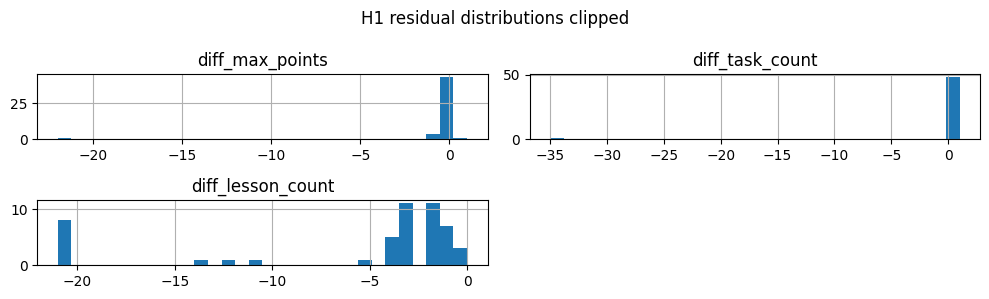

In [32]:
uc_course_ref = dfs["users_courses"].dropna(subset=["course_id"]).groupby("course_id").agg(uc_wk_max_points_median=("wk_max_points", "median"), uc_wk_max_task_count_median=("wk_max_task_count", "median"), uc_wk_max_viewable_lessons_median=("wk_max_viewable_lessons", "median"), uc_course_rows=("course_id", "size")).reset_index()
course_validation_AGENTS = uc_course_ref.merge(lessons_agg_AGENTS, on="course_id", how="left")
course_validation_AGENTS["diff_max_points"] = course_validation_AGENTS["uc_wk_max_points_median"] - course_validation_AGENTS["course_lessons_wk_max_points_sum"]
course_validation_AGENTS["diff_task_count"] = course_validation_AGENTS["uc_wk_max_task_count_median"] - course_validation_AGENTS["course_lessons_wk_task_count_sum"]
course_validation_AGENTS["diff_lesson_count"] = course_validation_AGENTS["uc_wk_max_viewable_lessons_median"] - course_validation_AGENTS["course_lessons_count"]
course_validation_clean = course_validation_AGENTS.loc[course_validation_AGENTS["uc_course_rows"].ge(MIN_COURSE_ROWS_FOR_COURSE_AUDIT)].copy()
h1_metrics_AGENTS = pd.DataFrame([{"metric": "courses_total", "value": len(course_validation_AGENTS)}, {"metric": "courses_clean_min_rows", "value": len(course_validation_clean)}, {"metric": "max_points_exact_share", "value": float(course_validation_clean["diff_max_points"].eq(0).mean())}, {"metric": "task_count_exact_share", "value": float(course_validation_clean["diff_task_count"].eq(0).mean())}, {"metric": "lesson_count_exact_share", "value": float(course_validation_clean["diff_lesson_count"].eq(0).mean())}, {"metric": "max_points_abs_diff_mean", "value": float(course_validation_clean["diff_max_points"].abs().mean())}, {"metric": "task_count_abs_diff_mean", "value": float(course_validation_clean["diff_task_count"].abs().mean())}, {"metric": "lesson_count_abs_diff_mean", "value": float(course_validation_clean["diff_lesson_count"].abs().mean())}])
display(h1_metrics_AGENTS)
display(course_validation_clean.sort_values("diff_lesson_count", key=lambda s: s.abs(), ascending=False).head(20))
plt.figure(figsize=(8, 3)); course_validation_clean[["diff_max_points", "diff_task_count", "diff_lesson_count"]].clip(-50, 50).hist(bins=30, figsize=(10, 3)); plt.suptitle("H1 residual distributions clipped"); plt.tight_layout(); plt.show()


### H2. Restored key bridge is sufficient for main course-activity tables

Why it matters: final features require joining `users_courses` with activity tables. Decision: use restored `users_course_id`, keep/drop unresolved rows through config, and keep audit flags.


,metric,value,section
0,total_student_user_course_pairs,2.672060e+05,resolution
1,resolved_pairs,2.079770e+05,resolution
2,unresolved_pairs,5.922900e+04,resolution
3,resolved_share,7.783396e-01,resolution
4,conflict_user_course_pairs_removed,0.000000e+00,resolution
5,conflict_user_ucid_pairs_removed,2.000000e+00,resolution
6,observed_student_users_course_id,2.086850e+05,resolution
7,unique_ids_total,2.086720e+05,coverage_user_lessons
8,unique_ids_total,2.085650e+05,coverage_wk_users_courses_actions
9,unique_ids_total,2.907840e+05,coverage_user_access_histories


,method,accepted_edges_before_global_conflict_check
3,evidence2_unique,199691
0,points_unique,195844
1,date_unique,99011
2,group_unique,51592
4,user_singleton,7390


,reason_bucket,pair_count
0,ambiguous_or_no_reliable_signal,35889
1,no_observed_users_course_id_for_user,23340


,course_id,unresolved_pair_count
9,763,27631
17,836,9708
14,770,6225
77,50000592,4470
78,170000688,2642
71,1061,2069
73,1096,1908
15,771,918
61,1033,633
72,1062,409


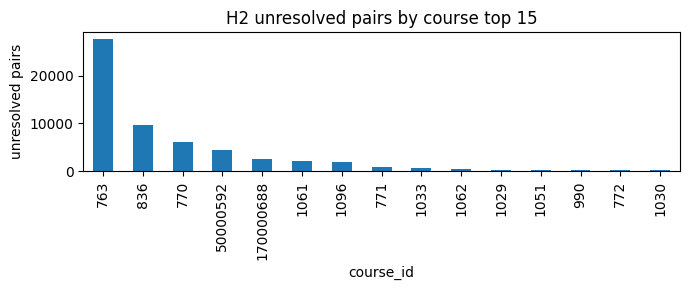

In [33]:
h2_metrics_AGENTS = pd.concat([key_resolution_audit_AGENTS.assign(section="resolution"), resolution_table_coverage_AGENTS.melt(id_vars="table", var_name="metric", value_name="value").assign(section=lambda x: "coverage_" + x["table"].astype(str))[['section','metric','value']]], ignore_index=True, sort=False)
display(h2_metrics_AGENTS.head(60))
display(method_acceptance_audit_AGENTS)
display(unresolved_reason_summary_AGENTS)
display(unresolved_course_summary_AGENTS.head(30))
plt.figure(figsize=(7, 3)); unresolved_course_summary_AGENTS.head(15).set_index("course_id")["unresolved_pair_count"].plot(kind="bar"); plt.title("H2 unresolved pairs by course top 15"); plt.xlabel("course_id"); plt.ylabel("unresolved pairs"); plt.tight_layout(); plt.show()


### H3. `user_activity_histories` partially overlaps WKA and is auxiliary

Why it matters: source EDA considered excluding `user_activity_histories`. Here we check bridge coverage and action/timestamp overlap. Decision: use it only as auxiliary features because WKA is the main course-action log.


,metric,value
0,uahist_rows,3.031137e+06
1,uahist_rows_joined_to_user_lessons,2.773902e+06
2,uahist_joined_row_share,9.151358e-01
3,uahist_unique_user_lesson_id,2.546319e+06


,ua_action,wka_actions,uah_first_at,uah_last_at,wka_first_at,wka_last_at,uah_events,wka_events
0,visit_video,visit_video,2020-12-03 21:28:00,2026-03-31 15:20:00,2025-02-17 11:35:00,2026-03-31 14:12:00,2642950,2557977
1,visit_translation,visit_translation,2020-11-25 13:36:00,2026-03-31 13:57:00,2025-03-06 10:13:00,2026-03-31 13:55:00,109847,93836
2,show_conspect,visit_preparation_material,2020-12-03 21:28:00,2026-03-31 15:16:00,2025-02-19 18:00:00,2026-03-13 06:21:00,278340,7658


,ua_action,uah_total_events,wka_total_events,covered_events_exact_ts,coverage_ratio_exact_ts
0,visit_video,2642950,2557977,2557949,0.967839
1,visit_translation,109847,93836,93833,0.854215
2,show_conspect,278340,7658,986,0.003542


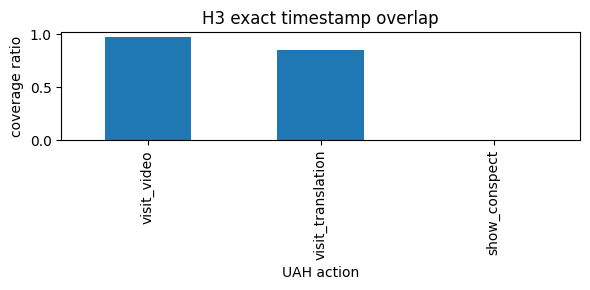

In [34]:
action_map_h3 = {"visit_video": ["visit_video"], "visit_translation": ["visit_translation"], "show_conspect": ["visit_preparation_material"]}
uah_for_h3 = dfs["user_activity_histories"].copy()
wka_for_h3 = dfs["wk_users_courses_actions"].copy()
h3_time_rows = []
h3_exact_rows = []
for ua_action, wka_actions in action_map_h3.items():
    ua_sub = uah_for_h3.loc[uah_for_h3["action_clean"].eq(clean_name(ua_action)), ["created_at"]].dropna()
    wka_sub = wka_for_h3.loc[wka_for_h3["action_clean"].isin([clean_name(a) for a in wka_actions]), ["created_at"]].dropna()
    h3_time_rows.append({"ua_action": ua_action, "wka_actions": "|".join(wka_actions), "uah_first_at": ua_sub["created_at"].min(), "uah_last_at": ua_sub["created_at"].max(), "wka_first_at": wka_sub["created_at"].min(), "wka_last_at": wka_sub["created_at"].max(), "uah_events": len(ua_sub), "wka_events": len(wka_sub)})
    ua_counts = ua_sub.groupby("created_at").size().rename("uah_count").reset_index()
    wka_counts_tmp = wka_sub.groupby("created_at").size().rename("wka_count").reset_index()
    cmp = ua_counts.merge(wka_counts_tmp, on="created_at", how="outer").fillna(0)
    cmp["covered_count"] = np.minimum(cmp["uah_count"], cmp["wka_count"])
    h3_exact_rows.append({"ua_action": ua_action, "uah_total_events": int(cmp["uah_count"].sum()), "wka_total_events": int(cmp["wka_count"].sum()), "covered_events_exact_ts": int(cmp["covered_count"].sum()), "coverage_ratio_exact_ts": float(cmp["covered_count"].sum() / cmp["uah_count"].sum()) if cmp["uah_count"].sum() else np.nan})
h3_time_bounds_AGENTS = pd.DataFrame(h3_time_rows)
h3_exact_overlap_AGENTS = pd.DataFrame(h3_exact_rows)
display(user_activity_bridge_audit_AGENTS)
display(h3_time_bounds_AGENTS)
display(h3_exact_overlap_AGENTS)
plt.figure(figsize=(6, 3)); h3_exact_overlap_AGENTS.set_index("ua_action")["coverage_ratio_exact_ts"].plot(kind="bar"); plt.title("H3 exact timestamp overlap"); plt.xlabel("UAH action"); plt.ylabel("coverage ratio"); plt.tight_layout(); plt.show()


### H4. Activity intensity is related to progress and weak success

Why it matters: churn and success are behavior-driven. WKA counts, active days and gaps should separate stronger vs weaker progress patterns.


,wka_event_bin,rows,mean_progress,success_proxy_rate,churn_proxy_rate,mean_active_days,mean_max_gap
0,"(0.999, 41577.4]",41577,0.635802,0.484066,0.96272,1.249128,4.339110
1,"(41577.4, 83153.8]",41576,0.681799,0.645517,0.990042,2.903839,11.613762
2,"(83153.8, 124730.2]",41577,0.802396,0.909878,0.996488,2.137817,6.699683
3,"(124730.2, 166306.6]",41576,0.788483,0.924379,0.996128,1.962887,4.270972
4,"(166306.6, 207883.0]",41577,0.665459,0.65541,0.988768,5.971811,10.675850
5,NaN,59323,0.147693,0.002107,0.0,NaN,NaN


<Figure size 800x300 with 0 Axes>

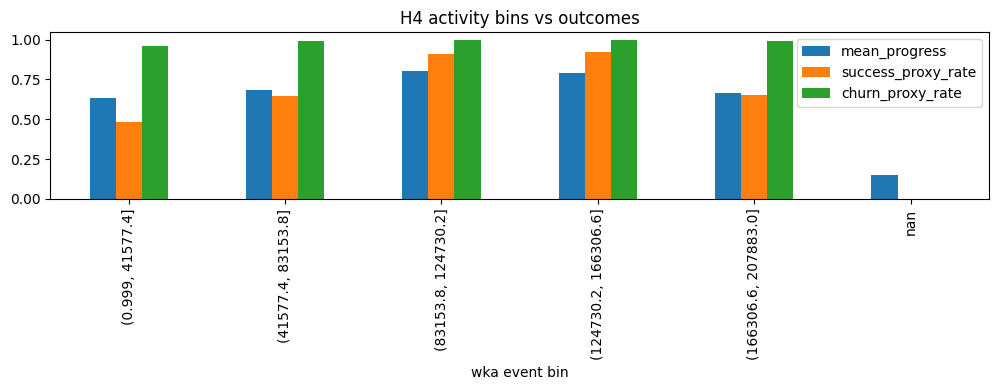

In [35]:
hyp_frame = base_entity_AGENTS[["user_id", "course_id", "users_course_id", "users_course_id_resolved_flag", "uc_points_ratio", "uc_is_completed_flag", "access_finished_at"]].copy()
hyp_frame = hyp_frame.merge(wka_features_AGENTS[["users_course_id", "wka_event_count", "wka_first_action_at", "wka_last_action_at", "wka_active_days", "wka_gap_days_max"]], on="users_course_id", how="left")
hyp_frame = hyp_frame.merge(user_lessons_features_AGENTS[["users_course_id", "ul_lesson_nunique", "ul_solved_lesson_share", "ul_points_sum"]], on="users_course_id", how="left")
hyp_frame = hyp_frame.merge(training_features_AGENTS[["user_id", "train_rows", "train_mark_mean", "train_mark_ge4_count"]], on="user_id", how="left")
hyp_frame["days_last_action_to_access_end"] = (hyp_frame["access_finished_at"] - hyp_frame["wka_last_action_at"]).dt.days
hyp_frame["churn_proxy_30d"] = (hyp_frame["users_course_id_resolved_flag"].eq(1) & hyp_frame["wka_event_count"].fillna(0).gt(0) & hyp_frame["uc_is_completed_flag"].eq(0) & hyp_frame["days_last_action_to_access_end"].ge(TARGET_INACTIVITY_DAYS)).astype("Int8")
hyp_frame["success_proxy_weak"] = (hyp_frame["uc_points_ratio"].ge(0.5) & hyp_frame["train_mark_ge4_count"].fillna(0).ge(4)).astype("Int8")
hyp_frame["wka_event_bin"] = pd.qcut(hyp_frame["wka_event_count"].rank(method="first"), q=5, duplicates="drop")
h4_bin_summary_AGENTS = hyp_frame.groupby("wka_event_bin", dropna=False).agg(rows=("user_id", "size"), mean_progress=("uc_points_ratio", "mean"), success_proxy_rate=("success_proxy_weak", "mean"), churn_proxy_rate=("churn_proxy_30d", "mean"), mean_active_days=("wka_active_days", "mean"), mean_max_gap=("wka_gap_days_max", "mean")).reset_index()
display(h4_bin_summary_AGENTS)
plt.figure(figsize=(8, 3)); h4_bin_summary_AGENTS.set_index("wka_event_bin")[["mean_progress", "success_proxy_rate", "churn_proxy_rate"]].plot(kind="bar", figsize=(10, 4)); plt.title("H4 activity bins vs outcomes"); plt.xlabel("wka event bin"); plt.tight_layout(); plt.show()


### H5. Last activity before access end is a churn-risk signal

Why it matters: the business churn definition explicitly depends on stopping activity before course end/access end.


,recency_bin,rows,churn_proxy_rate,mean_progress,completed_rate
0,after_end,194,0.0,0.316464,0.005155
1,same_day,124,0.0,0.389689,0.056452
2,1_7,509,0.0,0.388232,0.011788
3,8_14,346,0.0,0.384788,0.011561
4,15_30,1354,0.079025,0.446695,0.013294
5,31_60,2964,0.984143,0.401362,0.015857
6,61_120,17916,0.990511,0.594079,0.009489
7,120_plus,184476,0.999453,0.737349,0.000547
8,NaN,59323,0.0,0.147693,0.0


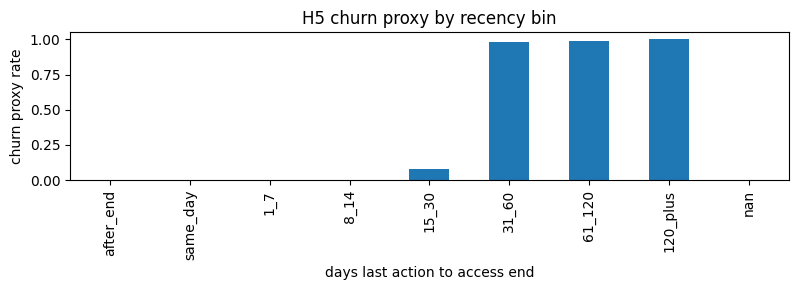

In [36]:
hyp_frame["recency_bin"] = pd.cut(hyp_frame["days_last_action_to_access_end"], bins=[-9999, -1, 0, 7, 14, 30, 60, 120, 9999], labels=["after_end", "same_day", "1_7", "8_14", "15_30", "31_60", "61_120", "120_plus"])
h5_recency_summary_AGENTS = hyp_frame.groupby("recency_bin", dropna=False).agg(rows=("user_id", "size"), churn_proxy_rate=("churn_proxy_30d", "mean"), mean_progress=("uc_points_ratio", "mean"), completed_rate=("uc_is_completed_flag", "mean")).reset_index()
display(h5_recency_summary_AGENTS)
plt.figure(figsize=(8, 3)); h5_recency_summary_AGENTS.set_index("recency_bin")["churn_proxy_rate"].plot(kind="bar"); plt.title("H5 churn proxy by recency bin"); plt.xlabel("days last action to access end"); plt.ylabel("churn proxy rate"); plt.tight_layout(); plt.show()


### H6. Access windows and repeated access can mark non-standard learning paths

Why it matters: repeated or long access may indicate extensions, interruptions or non-standard progression. Decision: include access counts and durations as interpretable features.


,access_rows_bin,rows,mean_progress,churn_proxy_rate,mean_access_window_days
0,no_access,59230,0.147829,0.000017,NaN
1,one,183466,0.720160,0.990314,181.322327
2,two,15723,0.655811,0.939579,236.274439
3,three_to_five,1343,0.659987,0.928518,210.994788
4,five_plus,7444,0.813525,0.998791,181.210774


<Figure size 800x300 with 0 Axes>

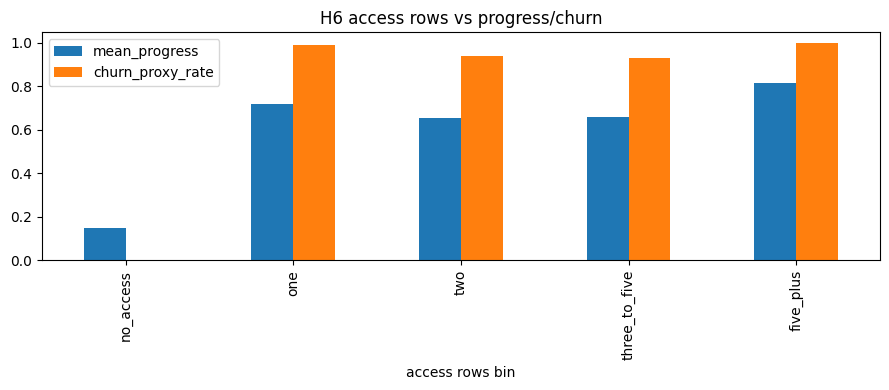

In [37]:
h6_frame = hyp_frame.merge(access_features_AGENTS[["users_course_id", "access_rows", "access_window_days", "access_activator_nunique"]], on="users_course_id", how="left")
h6_frame["access_rows_bin"] = pd.cut(h6_frame["access_rows"].fillna(0), bins=[-1, 0, 1, 2, 5, 999], labels=["no_access", "one", "two", "three_to_five", "five_plus"])
h6_access_summary_AGENTS = h6_frame.groupby("access_rows_bin", dropna=False).agg(rows=("user_id", "size"), mean_progress=("uc_points_ratio", "mean"), churn_proxy_rate=("churn_proxy_30d", "mean"), mean_access_window_days=("access_window_days", "mean")).reset_index()
display(h6_access_summary_AGENTS)
plt.figure(figsize=(8, 3)); h6_access_summary_AGENTS.set_index("access_rows_bin")[["mean_progress", "churn_proxy_rate"]].plot(kind="bar", figsize=(9, 4)); plt.title("H6 access rows vs progress/churn"); plt.xlabel("access rows bin"); plt.tight_layout(); plt.show()


### H7. User-level engagement enrichments are useful but not course-specific

Why it matters: media, badges and answers are user-level signals. They can improve baseline quality, but interpretation must be careful because they are not course-specific joins.


,feature,corr_with_progress,nonnull_share
5,answer_solved_share,0.454224,0.861145
3,badge_unique_count,0.409054,0.876010
2,badge_rows,0.409054,0.876010
6,answer_attempts_per_answer,0.253817,0.861145
7,answer_performance_mean,0.236495,0.861145
4,answer_rows,0.157171,0.861145
1,media_viewed_segments_share,0.049132,0.612962
0,media_sessions,0.023718,0.612962


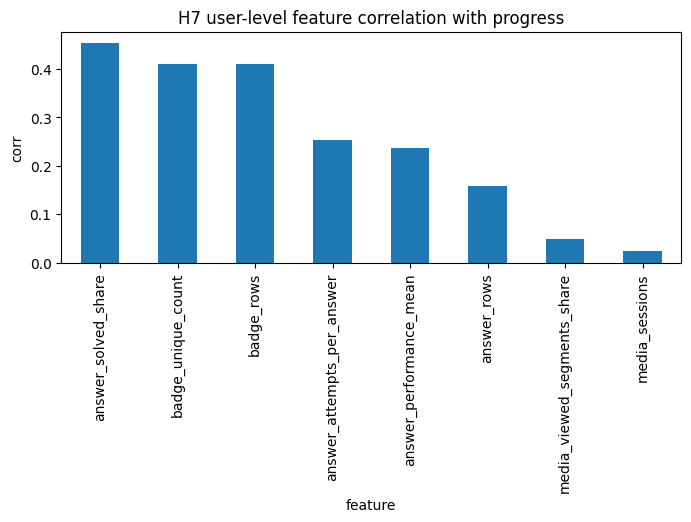

In [38]:
h7_frame = hyp_frame.merge(media_features_AGENTS[["user_id", "media_sessions", "media_viewed_segments_share"]], on="user_id", how="left").merge(award_features_AGENTS[["user_id", "badge_rows", "badge_unique_count"]], on="user_id", how="left").merge(answer_features_AGENTS[["user_id", "answer_rows", "answer_solved_share", "answer_attempts_per_answer", "answer_performance_mean"]], on="user_id", how="left")
engagement_cols = ["media_sessions", "media_viewed_segments_share", "badge_rows", "badge_unique_count", "answer_rows", "answer_solved_share", "answer_attempts_per_answer", "answer_performance_mean"]
h7_corr_rows = []
for col in engagement_cols:
    h7_corr_rows.append({"feature": col, "corr_with_progress": float(h7_frame[[col, "uc_points_ratio"]].corr().iloc[0, 1]) if h7_frame[col].notna().sum() > 1 else np.nan, "nonnull_share": float(h7_frame[col].notna().mean())})
h7_user_engagement_corr_AGENTS = pd.DataFrame(h7_corr_rows).sort_values("corr_with_progress", key=lambda s: s.abs(), ascending=False)
display(h7_user_engagement_corr_AGENTS)
plt.figure(figsize=(8, 3)); h7_user_engagement_corr_AGENTS.set_index("feature")["corr_with_progress"].plot(kind="bar"); plt.title("H7 user-level feature correlation with progress"); plt.xlabel("feature"); plt.ylabel("corr"); plt.tight_layout(); plt.show()


### H8. Target proxy distributions and leakage note

Why it matters: target-related columns are useful for analysis, but post-outcome fields must be excluded from a safer ML feature matrix.


,target_proxy,nonnull_rows,positive_rate
0,churn_proxy_30d,267206,0.767741
1,success_proxy_weak,267206,0.563614


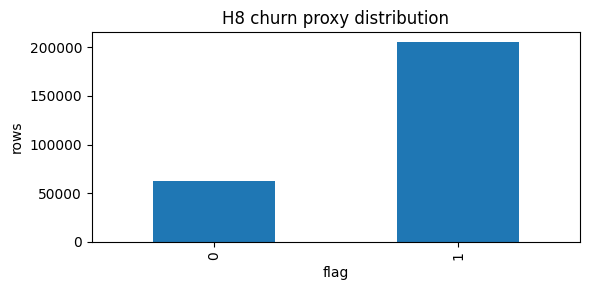

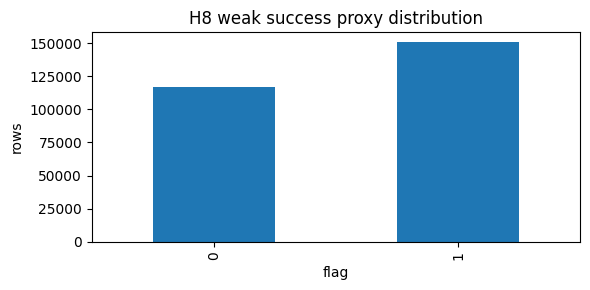

In [39]:
target_proxy_summary_AGENTS = pd.DataFrame([{"target_proxy": "churn_proxy_30d", "nonnull_rows": int(hyp_frame["churn_proxy_30d"].notna().sum()), "positive_rate": float(hyp_frame["churn_proxy_30d"].dropna().mean())}, {"target_proxy": "success_proxy_weak", "nonnull_rows": int(hyp_frame["success_proxy_weak"].notna().sum()), "positive_rate": float(hyp_frame["success_proxy_weak"].dropna().mean())}])
display(target_proxy_summary_AGENTS)
plt.figure(figsize=(6, 3)); hyp_frame["churn_proxy_30d"].value_counts(dropna=False).sort_index().plot(kind="bar"); plt.title("H8 churn proxy distribution"); plt.xlabel("flag"); plt.ylabel("rows"); plt.tight_layout(); plt.show()
plt.figure(figsize=(6, 3)); hyp_frame["success_proxy_weak"].value_counts(dropna=False).sort_index().plot(kind="bar"); plt.title("H8 weak success proxy distribution"); plt.xlabel("flag"); plt.ylabel("rows"); plt.tight_layout(); plt.show()


### Hypothesis interpretation table

This table is the compact analytical summary used later in `Hipotises_AGENTS.md`.


In [40]:
hypothesis_rows = []
for _, row in h1_metrics_AGENTS.iterrows():
    hypothesis_rows.append({"hypothesis": "H1_lessons_course_aggregation", "metric": row["metric"], "value": row["value"], "decision": "use_lessons_as_compact_course_features_with_audit"})
hypothesis_rows.extend([
    {"hypothesis": "H2_key_resolution", "metric": "resolved_share", "value": float(key_resolution_audit_AGENTS.loc[key_resolution_audit_AGENTS["metric"].eq("resolved_share"), "value"].iloc[0]), "decision": "use_restored_bridge_with_unresolved_policy"},
    {"hypothesis": "H3_user_activity_auxiliary", "metric": "uahist_joined_row_share", "value": float(user_activity_bridge_audit_AGENTS.loc[user_activity_bridge_audit_AGENTS["metric"].eq("uahist_joined_row_share"), "value"].iloc[0]), "decision": "use_as_auxiliary_not_replacement"},
    {"hypothesis": "H4_activity_intensity", "metric": "mean_wka_events_success_proxy_0", "value": float(hyp_frame.loc[hyp_frame["success_proxy_weak"].eq(0), "wka_event_count"].mean()), "decision": "use_wka_counts_active_days_gaps"},
    {"hypothesis": "H4_activity_intensity", "metric": "mean_wka_events_success_proxy_1", "value": float(hyp_frame.loc[hyp_frame["success_proxy_weak"].eq(1), "wka_event_count"].mean()), "decision": "use_wka_counts_active_days_gaps"},
    {"hypothesis": "H5_recency_churn", "metric": "churn_proxy_rate", "value": float(hyp_frame["churn_proxy_30d"].mean()), "decision": "use_recency_features_and_target_proxy"},
    {"hypothesis": "H6_access_windows", "metric": "mean_access_rows", "value": float(h6_frame["access_rows"].mean()), "decision": "use_access_count_and_duration_features"},
])
for _, row in h7_user_engagement_corr_AGENTS.iterrows():
    hypothesis_rows.append({"hypothesis": "H7_user_level_engagement", "metric": "corr_" + row["feature"], "value": row["corr_with_progress"], "decision": "use_as_user_level_enrichment"})
hypothesis_results_AGENTS = pd.DataFrame(hypothesis_rows)
display(hypothesis_results_AGENTS)


,hypothesis,metric,value,decision
0,H1_lessons_course_aggregation,courses_total,82.000000,use_lessons_as_compact_course_features_with_audit
1,H1_lessons_course_aggregation,courses_clean_min_rows,50.000000,use_lessons_as_compact_course_features_with_audit
2,H1_lessons_course_aggregation,max_points_exact_share,0.860000,use_lessons_as_compact_course_features_with_audit
3,H1_lessons_course_aggregation,task_count_exact_share,0.940000,use_lessons_as_compact_course_features_with_audit
4,H1_lessons_course_aggregation,lesson_count_exact_share,0.061224,use_lessons_as_compact_course_features_with_audit
5,H1_lessons_course_aggregation,max_points_abs_diff_mean,0.551020,use_lessons_as_compact_course_features_with_audit
6,H1_lessons_course_aggregation,task_count_abs_diff_mean,0.734694,use_lessons_as_compact_course_features_with_audit
7,H1_lessons_course_aggregation,lesson_count_abs_diff_mean,5.959184,use_lessons_as_compact_course_features_with_audit
8,H2_key_resolution,resolved_share,0.778340,use_restored_bridge_with_unresolved_policy
9,H3_user_activity_auxiliary,uahist_joined_row_share,0.915136,use_as_auxiliary_not_replacement


## 9. Join strategy and final merge

Join keys and expected cardinality:
- `course_id`: base many rows to one course feature row;
- `users_course_id`: base many rows including unresolved `NA`, but resolved ids map to one feature row;
- `user_id`: base many rows to one user-level feature row.

The merge audit proves that no row explosion happened.


In [41]:
merge_audit_rows = []
final_modeling_table_AGENTS = base_entity_AGENTS.copy()
feature_blocks = [("lessons_course_features", lessons_agg_AGENTS, ["course_id"]), ("user_lessons_features", user_lessons_features_AGENTS, ["users_course_id"]), ("wka_features", wka_features_AGENTS, ["users_course_id"]), ("access_features", access_features_AGENTS, ["users_course_id"]), ("user_activity_features", user_activity_features_AGENTS, ["users_course_id"]), ("users_features", users_features_AGENTS, ["user_id"]), ("training_features", training_features_AGENTS, ["user_id"]), ("media_features", media_features_AGENTS, ["user_id"]), ("award_features", award_features_AGENTS, ["user_id"]), ("answer_features", answer_features_AGENTS, ["user_id"])]
for name, block, keys in feature_blocks:
    final_modeling_table_AGENTS = merge_many_to_one(final_modeling_table_AGENTS, block, keys, name, merge_audit_rows)
merge_audit_AGENTS = pd.DataFrame(merge_audit_rows)
display(merge_audit_AGENTS)


,merge_name,keys,how,rows_before,rows_after,row_delta,base_duplicate_keys_before,add_duplicate_keys,duplicate_keys_after
0,lessons_course_features,course_id,left,267206,267206,0,267124,0,267124
1,user_lessons_features,users_course_id,left,267206,267206,0,59228,0,59228
2,wka_features,users_course_id,left,267206,267206,0,59228,0,59228
3,access_features,users_course_id,left,267206,267206,0,59228,0,59228
4,user_activity_features,users_course_id,left,267206,267206,0,59228,0,59228
5,users_features,user_id,left,267206,267206,0,182634,0,182634
6,training_features,user_id,left,267206,267206,0,182634,0,182634
7,media_features,user_id,left,267206,267206,0,182634,0,182634
8,award_features,user_id,left,267206,267206,0,182634,0,182634
9,answer_features,user_id,left,267206,267206,0,182634,0,182634


### 9.1 Missing policy after merge

For resolved ids, missing course-activity counts are filled with zero when the semantic meaning is no observed event. For unresolved ids, course-activity fields remain `NA` because the bridge is unknown.


In [42]:
resolved_mask = final_modeling_table_AGENTS["users_course_id_resolved_flag"].eq(1)
course_event_prefixes = ("ul_", "wka_", "access_", "uahist_")
course_event_numeric_cols = [c for c in final_modeling_table_AGENTS.columns if c.startswith(course_event_prefixes) and pd.api.types.is_numeric_dtype(final_modeling_table_AGENTS[c])]
for col in course_event_numeric_cols:
    final_modeling_table_AGENTS.loc[resolved_mask, col] = final_modeling_table_AGENTS.loc[resolved_mask, col].fillna(0)
user_level_prefixes = ("train_", "media_", "badge_", "answer_")
user_level_numeric_cols = [c for c in final_modeling_table_AGENTS.columns if c.startswith(user_level_prefixes) and pd.api.types.is_numeric_dtype(final_modeling_table_AGENTS[c])]
for col in user_level_numeric_cols:
    final_modeling_table_AGENTS[col] = final_modeling_table_AGENTS[col].fillna(0)
zero_series = pd.Series(0, index=final_modeling_table_AGENTS.index)
final_modeling_table_AGENTS["maybe_action_data_missing_flag"] = (final_modeling_table_AGENTS["users_course_id_resolved_flag"].eq(0) | (final_modeling_table_AGENTS.get("wka_event_count", zero_series).fillna(0).eq(0) & final_modeling_table_AGENTS.get("ul_rows", zero_series).fillna(0).eq(0))).astype("Int8")


### 9.2 Target-related columns and leakage notes

`target_churn_proxy_30d_flag` follows the case description in simplified form: activity existed, then no action for at least 30 days before access end, and course was not completed. `target_success_proxy_weak_flag` is a weak approximation because the exact 4 intermediate tests are not reliably course-keyed in raw data.


In [43]:
final_modeling_table_AGENTS["days_last_action_to_access_end"] = (final_modeling_table_AGENTS["access_finished_at"] - final_modeling_table_AGENTS["wka_last_action_at"]).dt.days
final_modeling_table_AGENTS["target_had_course_activity_flag"] = (final_modeling_table_AGENTS["users_course_id_resolved_flag"].eq(1) & (final_modeling_table_AGENTS.get("wka_event_count", zero_series).fillna(0).gt(0) | final_modeling_table_AGENTS.get("ul_rows", zero_series).fillna(0).gt(0))).astype("Int8")
final_modeling_table_AGENTS["target_churn_proxy_30d_flag"] = (final_modeling_table_AGENTS["target_had_course_activity_flag"].eq(1) & final_modeling_table_AGENTS["uc_is_completed_flag"].eq(0) & final_modeling_table_AGENTS["days_last_action_to_access_end"].ge(TARGET_INACTIVITY_DAYS)).astype("Int8")
final_modeling_table_AGENTS.loc[final_modeling_table_AGENTS["users_course_id_resolved_flag"].eq(0), "target_churn_proxy_30d_flag"] = pd.NA
final_modeling_table_AGENTS["target_success_proxy_weak_flag"] = (final_modeling_table_AGENTS["uc_points_ratio"].ge(0.5) & final_modeling_table_AGENTS.get("train_mark_ge4_count", zero_series).fillna(0).ge(4)).astype("Int8")
leakage_note_AGENTS = pd.DataFrame([{"column": col, "leakage_risk": "target_or_post_outcome", "recommendation": "exclude_from_safe_feature_matrix"} for col in ["wk_course_completed_at", "uc_is_completed_flag", "target_churn_proxy_30d_flag", "target_success_proxy_weak_flag"] if col in final_modeling_table_AGENTS.columns])
display(leakage_note_AGENTS)


,column,leakage_risk,recommendation
0,wk_course_completed_at,target_or_post_outcome,exclude_from_safe_feature_matrix
1,uc_is_completed_flag,target_or_post_outcome,exclude_from_safe_feature_matrix
2,target_churn_proxy_30d_flag,target_or_post_outcome,exclude_from_safe_feature_matrix
3,target_success_proxy_weak_flag,target_or_post_outcome,exclude_from_safe_feature_matrix


## 10. Final dataset audit

This audit checks row counts, grain uniqueness, merge coverage, missingness, target distributions and sanity plots.


,metric,value
0,final_rows,267206.000000
1,final_duplicate_user_course,0.000000
2,final_resolved_share,0.778340
3,final_action_missing_share,0.221660
4,target_churn_proxy_30d_rate_nonnull,0.986383
5,target_success_proxy_weak_rate,0.563614


,column,missing_count,missing_share,dtype
0,wk_course_completed_at,266852,0.998675,datetime64[ns]
1,wk_gender,252213,0.943890,float64
2,wk_officially_started_at,170345,0.637504,datetime64[ns]
3,uc_days_start_to_official_start,170345,0.637504,float64
4,media_first_started_at,103419,0.387038,datetime64[ns]
5,media_last_started_at,103419,0.387038,datetime64[ns]
6,d_wk_school_id,99873,0.373768,Int64
7,d_wk_municipal_id,99873,0.373768,Int64
8,d_wk_region_id,99873,0.373768,Int64
9,uahist_first_at,73918,0.276633,datetime64[ns]


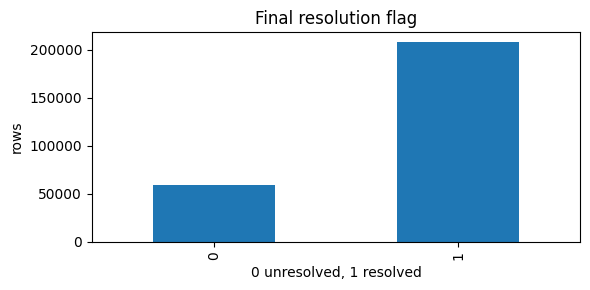

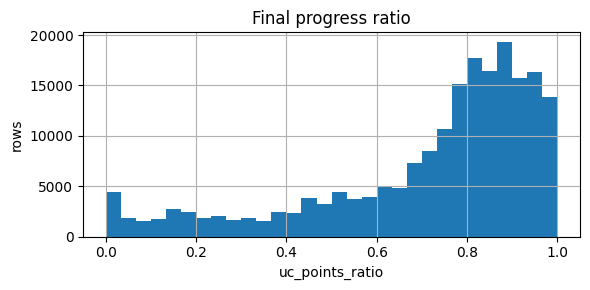

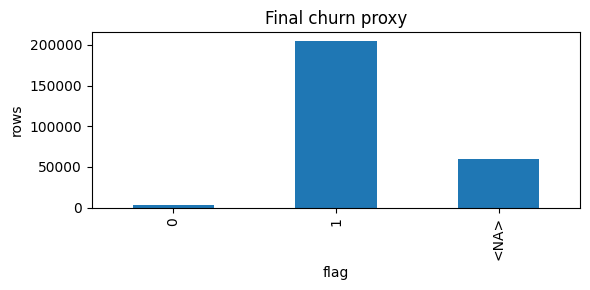

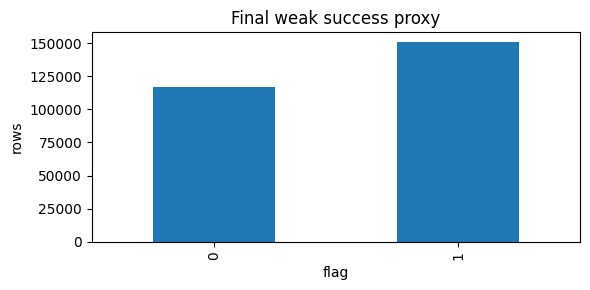

In [44]:
final_audit_AGENTS = pd.DataFrame([{"metric": "final_rows", "value": len(final_modeling_table_AGENTS)}, {"metric": "final_duplicate_user_course", "value": int(final_modeling_table_AGENTS.duplicated(["user_id", "course_id"]).sum())}, {"metric": "final_resolved_share", "value": float(final_modeling_table_AGENTS["users_course_id_resolved_flag"].mean())}, {"metric": "final_action_missing_share", "value": float(final_modeling_table_AGENTS["maybe_action_data_missing_flag"].mean())}, {"metric": "target_churn_proxy_30d_rate_nonnull", "value": float(final_modeling_table_AGENTS["target_churn_proxy_30d_flag"].dropna().mean())}, {"metric": "target_success_proxy_weak_rate", "value": float(final_modeling_table_AGENTS["target_success_proxy_weak_flag"].mean())}])
missingness_audit_AGENTS = missingness_table(final_modeling_table_AGENTS, top_n=250)
display(final_audit_AGENTS)
display(missingness_audit_AGENTS.head(60))
plot_bar(final_modeling_table_AGENTS["users_course_id_resolved_flag"].value_counts().sort_index(), "Final resolution flag", "0 unresolved, 1 resolved", "rows")
plt.figure(figsize=(6, 3)); final_modeling_table_AGENTS["uc_points_ratio"].clip(0, 1).hist(bins=30); plt.title("Final progress ratio"); plt.xlabel("uc_points_ratio"); plt.ylabel("rows"); plt.tight_layout(); plt.show()
plot_bar(final_modeling_table_AGENTS["target_churn_proxy_30d_flag"].value_counts(dropna=False).sort_index(), "Final churn proxy", "flag", "rows")
plot_bar(final_modeling_table_AGENTS["target_success_proxy_weak_flag"].value_counts(dropna=False).sort_index(), "Final weak success proxy", "flag", "rows")


## 11. Export artifacts

All exports use ASCII names and are written only to `data/AGENTS`. CSV is used because this environment has no parquet engine installed.


In [45]:
source_overview_AGENTS.to_csv(OUTPUT_DIR / "source_overview_AGENTS.csv", index=False, encoding="utf-8")
duplicate_audit_AGENTS.to_csv(OUTPUT_DIR / "source_duplicate_audit_AGENTS.csv", index=False, encoding="utf-8")
teacher_filter_audit_AGENTS.to_csv(OUTPUT_DIR / "teacher_filter_audit_AGENTS.csv", index=False, encoding="utf-8")
resolution_mapping_AGENTS.to_csv(OUTPUT_DIR / "resolution_mapping_AGENTS.csv", index=False, encoding="utf-8", na_rep="NA")
key_resolution_audit_AGENTS.to_csv(OUTPUT_DIR / "key_resolution_audit_AGENTS.csv", index=False, encoding="utf-8")
resolution_table_coverage_AGENTS.to_csv(OUTPUT_DIR / "resolution_table_coverage_AGENTS.csv", index=False, encoding="utf-8")
unresolved_reason_summary_AGENTS.to_csv(OUTPUT_DIR / "unresolved_reason_summary_AGENTS.csv", index=False, encoding="utf-8")
unresolved_course_summary_AGENTS.to_csv(OUTPUT_DIR / "unresolved_course_summary_AGENTS.csv", index=False, encoding="utf-8")
user_activity_bridge_audit_AGENTS.to_csv(OUTPUT_DIR / "user_activity_bridge_audit_AGENTS.csv", index=False, encoding="utf-8")
h1_metrics_AGENTS.to_csv(OUTPUT_DIR / "h1_course_validation_metrics_AGENTS.csv", index=False, encoding="utf-8")
h3_time_bounds_AGENTS.to_csv(OUTPUT_DIR / "h3_uah_wka_time_bounds_AGENTS.csv", index=False, encoding="utf-8")
h3_exact_overlap_AGENTS.to_csv(OUTPUT_DIR / "h3_uah_wka_exact_overlap_AGENTS.csv", index=False, encoding="utf-8")
h4_bin_summary_AGENTS.to_csv(OUTPUT_DIR / "h4_activity_bin_summary_AGENTS.csv", index=False, encoding="utf-8")
h5_recency_summary_AGENTS.to_csv(OUTPUT_DIR / "h5_recency_summary_AGENTS.csv", index=False, encoding="utf-8")
h6_access_summary_AGENTS.to_csv(OUTPUT_DIR / "h6_access_summary_AGENTS.csv", index=False, encoding="utf-8")
h7_user_engagement_corr_AGENTS.to_csv(OUTPUT_DIR / "h7_user_engagement_corr_AGENTS.csv", index=False, encoding="utf-8")
target_proxy_summary_AGENTS.to_csv(OUTPUT_DIR / "target_proxy_summary_AGENTS.csv", index=False, encoding="utf-8")
hypothesis_results_AGENTS.to_csv(OUTPUT_DIR / "hypothesis_results_AGENTS.csv", index=False, encoding="utf-8")
merge_audit_AGENTS.to_csv(OUTPUT_DIR / "merge_audit_AGENTS.csv", index=False, encoding="utf-8")
missingness_audit_AGENTS.to_csv(OUTPUT_DIR / "missingness_audit_AGENTS.csv", index=False, encoding="utf-8")
final_audit_AGENTS.to_csv(OUTPUT_DIR / "final_audit_AGENTS.csv", index=False, encoding="utf-8")
leakage_note_AGENTS.to_csv(OUTPUT_DIR / "feature_leakage_notes_AGENTS.csv", index=False, encoding="utf-8")
final_modeling_table_AGENTS.to_csv(OUTPUT_DIR / "final_modeling_table_AGENTS.csv", index=False, encoding="utf-8", na_rep="NA")
feature_dictionary_AGENTS = pd.DataFrame([{"column": col, "dtype": str(final_modeling_table_AGENTS[col].dtype), "source_hint": col.split("_")[0], "note": "generated_by_EDA_AGENT_pipeline"} for col in final_modeling_table_AGENTS.columns])
feature_dictionary_AGENTS.to_csv(OUTPUT_DIR / "feature_dictionary_AGENTS.csv", index=False, encoding="utf-8")

hyp_md = """# Hipotises_AGENTS

## Goal
Keep only hypotheses that were checked and used in final EDA or feature engineering.

## Confirmed hypotheses

1. H1_lessons_course_aggregation
- Check: compare sums/counts from `lessons` with canonical medians in `users_courses`.
- Result: useful but not perfect, especially for lesson counts.
- Consequence: use compact course features with audit, do not overwrite `users_courses`.

2. H2_key_resolution
- Check: restore `(user_id, course_id) -> users_course_id`, inspect conflicts and table coverage.
- Result: bridge covers main observed activity ids very well; unresolved rows are controlled by config.
- Consequence: all course-activity joins use restored `users_course_id`.

3. H3_user_activity_auxiliary
- Check: bridge `user_activity_histories.user_lesson_id` to `user_lessons.user_lesson_row_id` and compare overlap with WKA actions.
- Result: useful partial auxiliary source, not a replacement for WKA.
- Consequence: include auxiliary UAH action counts only with audit.

4. H4_activity_intensity
- Check: WKA event bins vs progress and weak success proxy.
- Result: activity intensity separates behavior patterns.
- Consequence: use WKA counts, active days, spans and gaps.

5. H5_recency_churn
- Check: last action to access end bins vs churn proxy.
- Result: recency is aligned with churn definition.
- Consequence: use recency and target proxy columns.

6. H6_access_windows
- Check: access row bins vs progress and churn proxy.
- Result: access history is useful as non-standard path context.
- Consequence: use access counts and duration features.

7. H7_user_level_engagement
- Check: user-level media, badge and answer correlations with progress.
- Result: useful as enrichment, but not course-specific.
- Consequence: join by `user_id` and interpret carefully.

## Rejected or limited hypotheses

- Raw ids are not used as predictive features.
- `user_answers`, `user_trainings`, `wk_media_view_sessions`, and badges are not treated as course-level without a verified course key.
- `user_activity_histories` is not used as full replacement for `wk_users_courses_actions`.
"""
(OUTPUT_DIR / "Hipotises_AGENTS.md").write_text(hyp_md, encoding="utf-8")
exported_files_AGENTS = pd.DataFrame([{"artifact": p.name, "path": str(p), "size_bytes": p.stat().st_size} for p in sorted(OUTPUT_DIR.glob("*_AGENTS.*"))])
display(exported_files_AGENTS)


,artifact,path,size_bytes
0,feature_dictionary_AGENTS.csv,C:\Repos\Xakaton\data\AGENTS\feature_dictionary_AGENTS.csv,11107
1,feature_leakage_notes_AGENTS.csv,C:\Repos\Xakaton\data\AGENTS\feature_leakage_notes_AGENTS.csv,367
2,final_audit_AGENTS.csv,C:\Repos\Xakaton\data\AGENTS\final_audit_AGENTS.csv,263
3,final_modeling_table_AGENTS.csv,C:\Repos\Xakaton\data\AGENTS\final_modeling_table_AGENTS.csv,276120313
4,h1_course_validation_metrics_AGENTS.csv,C:\Repos\Xakaton\data\AGENTS\h1_course_validation_metrics_AGENTS.csv,304
5,h3_uah_wka_exact_overlap_AGENTS.csv,C:\Repos\Xakaton\data\AGENTS\h3_uah_wka_exact_overlap_AGENTS.csv,259
6,h3_uah_wka_time_bounds_AGENTS.csv,C:\Repos\Xakaton\data\AGENTS\h3_uah_wka_time_bounds_AGENTS.csv,480
7,h4_activity_bin_summary_AGENTS.csv,C:\Repos\Xakaton\data\AGENTS\h4_activity_bin_summary_AGENTS.csv,764
8,h5_recency_summary_AGENTS.csv,C:\Repos\Xakaton\data\AGENTS\h5_recency_summary_AGENTS.csv,620
9,h6_access_summary_AGENTS.csv,C:\Repos\Xakaton\data\AGENTS\h6_access_summary_AGENTS.csv,423


## 12. Final summary

Built:
- structured EDA with table-by-table rough preprocessing;
- key restoration pipeline close to `Resolve_AGENT.ipynb`;
- expanded hypothesis checks H1-H8;
- interpretable feature blocks by source;
- final modeling table in grain `(user_id, course_id)`;
- audit tables for resolution, joins, missingness, leakage and outputs.

Unresolved handling:
- controlled by top-level `UNRESOLVED_MODE`;
- `keep` keeps unresolved rows and preserves unknown course-activity features as `NA`;
- `drop` removes unresolved rows from final export.
